#  NOTEBOOK 2 — Exploratory Data Analysis
# Title : "North Africa M&E — Exploratory Data Analysis"

## Dataset
The analysis relies on a dataset constructed by cleaning and merging data from FAO, WHO, and the World Bank (Notebook1).

- **Dataset 1 — FAOSTAT (Suite of Food Security Indicators)**  
Food Security and Nutrition : https://www.fao.org/faostat/en/#data  
**Indicators:**<br>- Prevalence of undernourishment <br>- Food supply (kcal/capita/day)<br>- Access to safe drinking water   

- **Dataset 2 — World Bank Governance Indicators**  
https://databank.worldbank.org/source/worldwide-governance-indicators  
**Indicators:**<br>- Government Effectiveness<br>- Rule of Law<br>- Control of Corruption<br>- Voice and Accountability  

- **Dataset 3 — World Health Organisation Governance Indicators**
https://www.who.int/data/gho/data/indicators  
**Indicators:**<br>- Life expectancy at birth<br>- Health expenditure (% of GDP)<br>- Maternal mortality ratio   

**Countries:** Tunisia, Algeria, Morocoo, Egypte, Libya   
**Year:** 2000 – 2023  


## Research Objectives
1. Has governance quality improved or deteriorated across North Africa (2000–2023)?
2. Is there a measurable link between governance quality and food security outcomes?
3. Does governance affect health outcomes directly or through food security (mediation)?
4. What was the measurable impact of the 2011 Arab Spring on governance indicators?
5. Which country shows the most coherent multi-dimensional development trajectory?

## 1. Evolution of indicators by country

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('north_africa_final_clean.csv')

countries = ['Tunisia', 'Algeria', 'Morocco', 'Egypt', 'Libya']


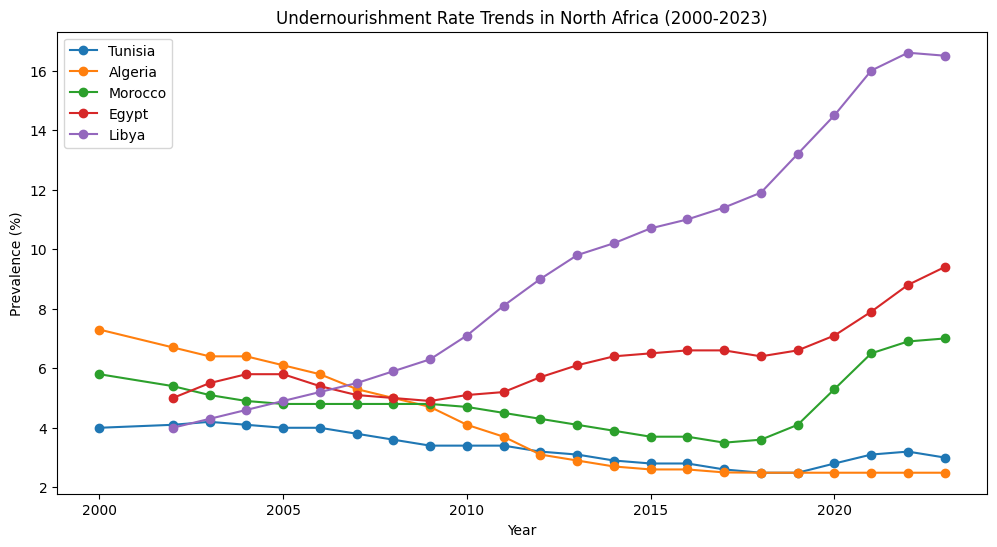

In [2]:
# Evolution of undernourishment by country
plt.figure(figsize=(12, 6))

for country in countries:
    # Filter the DataFrame for each country and the specific indicator
    data = df[(df['Country'] == country)]
    
    # Plot the trend line for this country
    plt.plot(data['Year'], data['Undernourishment_pct'], marker='o', label=country)

# Fix the spacing of Y-axis ticks
#plt.yticks(np.arange(0, 25, 5))   # from 0 to 25, step of 5

# Add titles and labels
plt.title('Undernourishment Rate Trends in North Africa (2000-2023)')
plt.xlabel('Year')
plt.ylabel('Prevalence (%)')

# Add legend
plt.legend()

# Save the figure
plt.savefig('undernourishment_trends.png')

# Show the plot
plt.show()

- Tunisia: A downward trend, with very low rates (<2.5%). This reflects strong food security and resilience against economic or climatic shocks.
- Algeria: Similar trajectory to Tunisia, with a steady decline and the lowest rate in the region by 2023 (~2%).
- Morocco: Decline until 2015, followed by an increase. This suggests initial improvement but later vulnerabilities linked to economic or climatic factors.
- Egypt: A slow but continuous rise in undernourishment, indicating growing pressure on food security despite a relatively stable baseline.
- Libya: A sharp and constant increase since 2011, reaching ~16% in 2023. This deterioration aligns with political and economic crises that weakened the country.

This graph highlights that food security in North Africa is strongly dependent on political and economic stability. Stable countries (Tunisia, Algeria) maintain very low rates, while countries in crisis (Libya, Egypt) see their indicators worsen. Morocco illustrates a fluctuating situation, sensitive to external shocks.  
👉 In summary: institutional stability and governance are decisive factors for food security in the region.


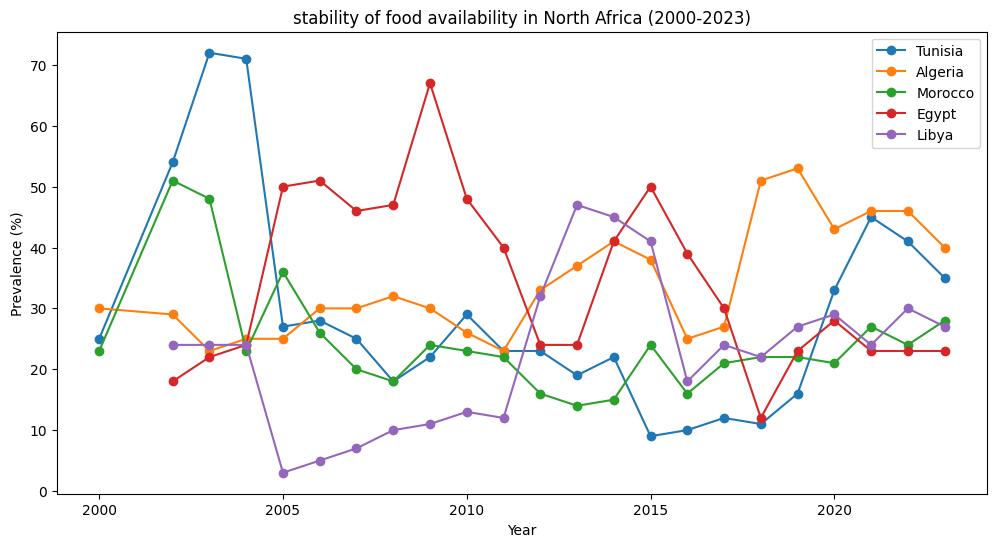

In [3]:
# Evolution of the stability of food availability

plt.figure(figsize=(12, 6))

for country in countries:
    # Filter the DataFrame for each country and the specific indicator
    data = df[(df['Country'] == country)]
    
    # Plot the trend line for this country
    plt.plot(data['Year'], data['FoodSupply_variability'], marker='o', label=country)

# Fix the spacing of Y-axis ticks
#plt.yticks(np.arange(0, 25, 5))   # from 0 to 25, step of 5

# Add titles and labels
plt.title('stability of food availability in North Africa (2000-2023)')
plt.xlabel('Year')
plt.ylabel('Prevalence (%)')

# Add legend
plt.legend()

# Save the figure
plt.savefig('foodavailability_trends.png')

# Show the plot
plt.show()


- Tunisia started as the most volatile country in the early 2000s but improved significantly by 2017-2018, before deteriorating again post-2020 due to COVID-19 and its economic crisis.
- Algeria shows the most worrying trend — steadily worsening since 2017, reflecting growing import dependency and vulnerability to external shocks.
- Morocco remains the most stable throughout the period, consistent with sustained agricultural investment and diversification policies.
- Egypt experienced a dramatic spike around 2009-2010 — a delayed effect of the 2007-2008 global food price crisis — before partially recovering.
- Libya shows low early values (likely due to data gaps) followed by rising instability after 2014, directly linked to post-2011 political conflict disrupting food supply chains.  
One pattern is common to all five countries : a post-2020 deterioration, reflecting the combined shock of COVID-19, the Ukraine war, and global supply chain disruptions.

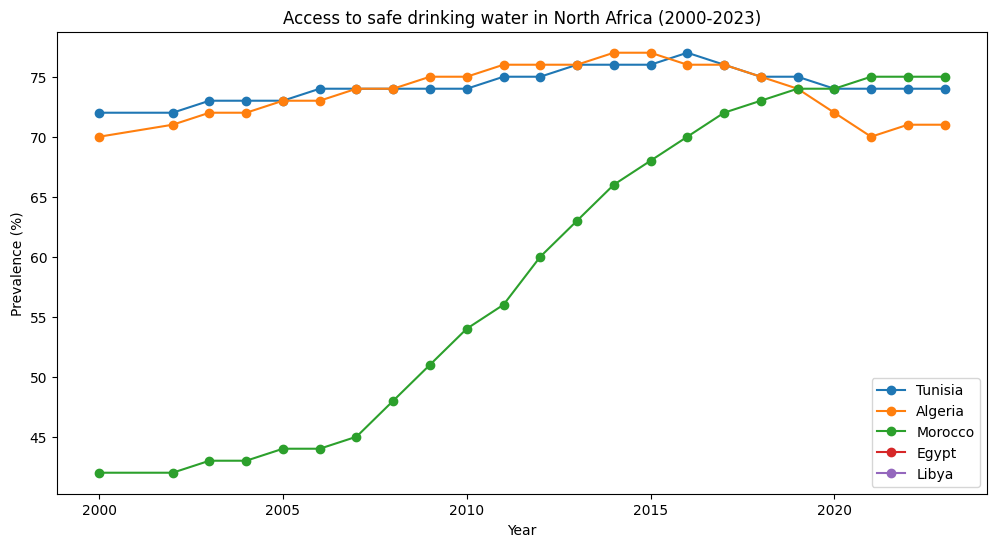

In [4]:
# Access to safe drinking water

plt.figure(figsize=(12, 6))

for country in countries:
    # Filter the DataFrame for each country and the specific indicator
    data = df[
        (df['Country'] == country)]
    
    # Plot the trend line for this country
    plt.plot(data['Year'], data['SafeWater_pct'], marker='o', label=country)

# Fix the spacing of Y-axis ticks
#plt.yticks(np.arange(0, 25, 5))   # from 0 to 25, step of 5

# Add titles and labels
plt.title('Access to safe drinking water in North Africa (2000-2023)')
plt.xlabel('Year')
plt.ylabel('Prevalence (%)')

# Add legend
plt.legend()

# Save the figure
plt.savefig('foodavailability_trends.png')

# Show the plot
plt.show()


- The most striking story is Morocco's dramatic progress. Starting from just 42% in 2000, Morocco achieved a near-doubling of access to safe drinking water by 2023 (~75%), showing the steepest and most consistent improvement in the region over two decades — a remarkable policy success.
- Tunisia and Algeria began the period at similar levels (~72% and 70% respectively) and both improved gradually, peaking around 2015-2017 at approximately 77-78%. However, both show a concerning decline post-2020, with Algeria dropping noticeably to ~71% by 2022 — likely reflecting infrastructure strain, climate-related water scarcity, and fiscal pressures on public services.
- Egypt and Libya are absent from the graph because no data are available on the FAO website for this specific indicator—an important limitation to acknowledge in any analysis

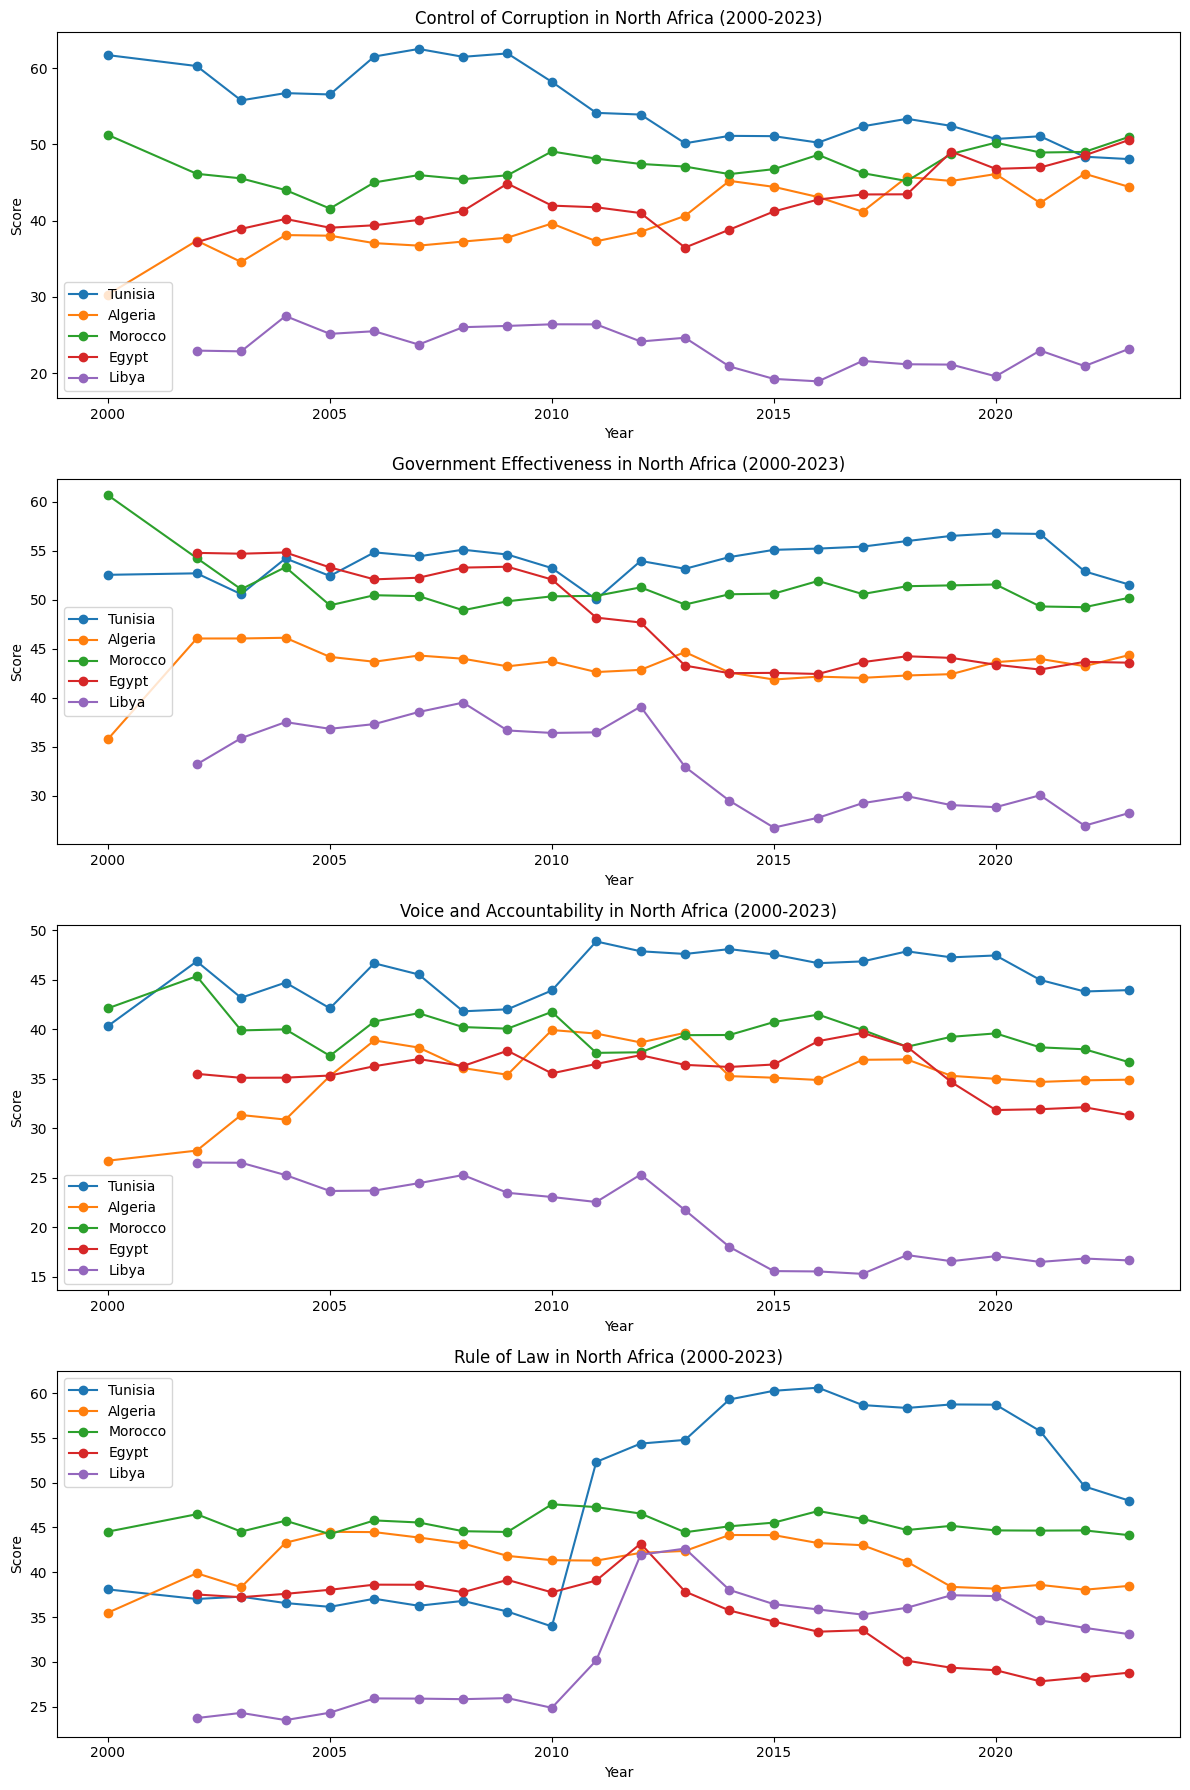

In [6]:
Indicator = ['Gov_Effectiveness',
    'Rule_of_Law',
    'Control_Corruption',
    'Voice_Accountability']

Title = ['Control of Corruption in North Africa (2000-2023)', 'Government Effectiveness in North Africa (2000-2023)', 
         'Voice and Accountability in North Africa (2000-2023)', 'Rule of Law in North Africa (2000-2023)']

# Create 4 subplots (one for each governance indicator)
fig, axes = plt.subplots(4, 1, figsize=(12, 18))  # 4 rows, 1 column

# Loop through indicators and titles in parallel
for ax, indicator, title in zip(axes, Indicator, Title):
    for country in countries:
        # Filter the DataFrame for each country and specific indicator
        data = df[
            (df['Country'] == country) &
            (df[indicator] )
        ].sort_values('Year')
        
        # Plot the trend line for this country
        ax.plot(data['Year'].unique(), data[indicator].unique(), marker='o', label=country)
    
    # Add titles and labels
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel('Score')
    ax.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Save the figure
plt.savefig('Governance_trends.png')

# Show the plot
plt.show()


📊 Governance Trends in North Africa (2000–2023) — Key Findings  
🔵 Tunisia — The Most Instructive CaseTunisia presents the most contrasted and analytically rich profile in the region:
- Control of Corruption: Consistent regional leader until 2020, then notable decline — a post-revolution warning signal  
- Government Effectiveness: Strong in 2000 ( approx. 62), progressive erosion through 2023 (~48) — visible institutional weakening
- Voice & Accountability: Spectacular spike post-2011 (Jasmine Revolution → +20 points), then regression since 2019 — documented authoritarian backsliding
- Rule of Law: Relatively stable but with a recent slight downward trend.  
Key finding: The 2011 Revolution produced a real but temporary democratic gain. Institutional consolidation did not follow.

🟢 Morocco — Steady Progress
- Government Effectiveness: Consistent upward trend, converging with Tunisia in 2023 (~50) — a significant convergence
- Rule of Law: Stable and solid (~50) — the strongest regional performance on this indicator
- Voice & Accountability: Gradual improvement, the most sustained in the region
- Control of Corruption: Stable around 40  
Key finding: Morocco is the only country showing consistent multi-indicator improvement over 23 years — a model of gradual reform.

🟠 Algeria — Stagnation
- All indicators oscillate within a narrow band of 35–45 with no clear trend
- Slight recent improvement in Government Effectiveness
- Voice & Accountability remains low and stable (~38–44)
Key finding: Absence of structural reform — apparent stability masking institutional stagnation.  

🔴 Egypt — The Authoritarian Trajectory
- Voice & Accountability: Peak in 2011–2012 (Arab Spring), then sharp collapse → lowest regional level in 2023 (~29)
- Control of Corruption: Progressive decline
- Government Effectiveness: Slight recent improvement, but at the cost of civil liberties
Key finding: A classic post-transition authoritarian consolidation — efficiency gains traded against the erosion of freedoms.  

🟣 Libya — Post-Conflict Collapse
- All indicators collapse after 2011 (civil war)
- Control of Corruption: Drop from 25 to 15 — the lowest in the region
- Government Effectiveness: ~22 in 2023 — near-absence of a functioning state
- Slight stabilisation since 2017 but at very low levels
Key finding: A textbook illustration of armed conflict's impact on institutions — no indicator is spared.


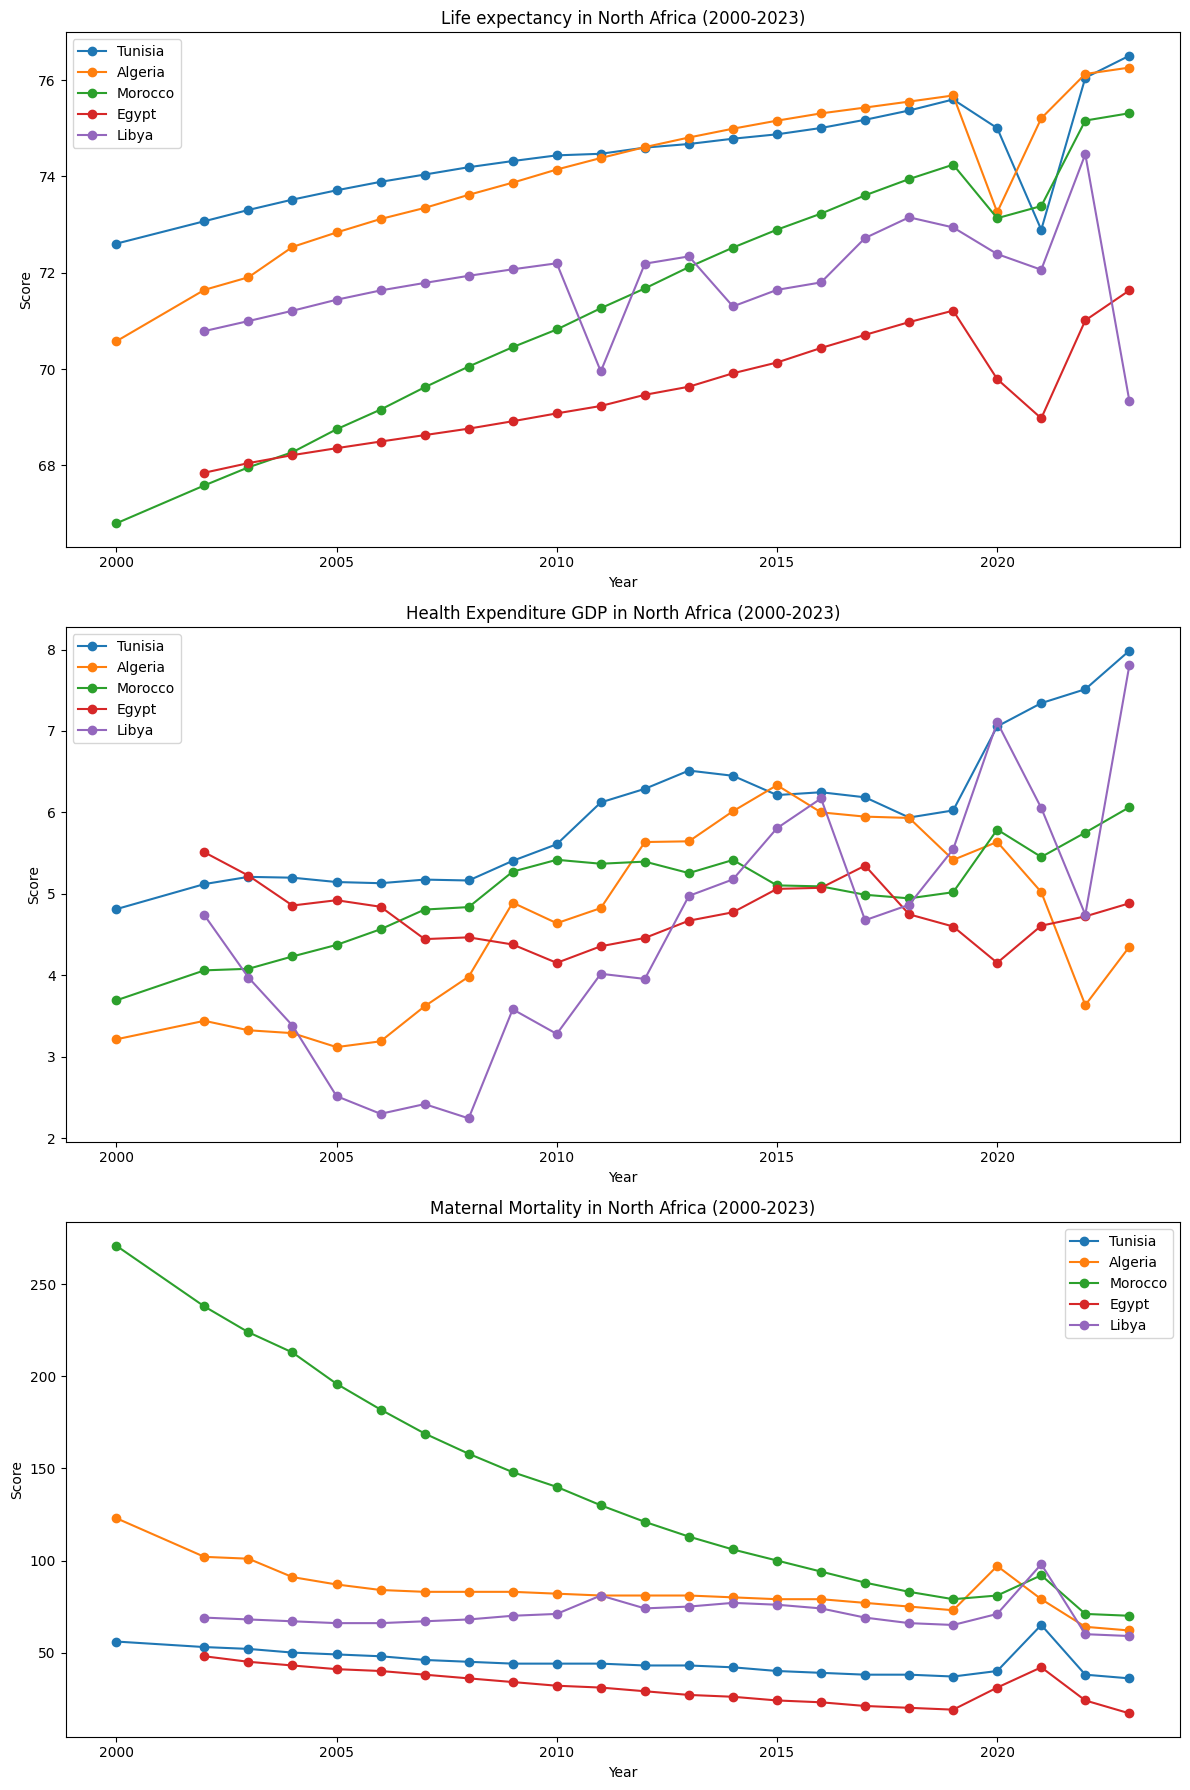

In [7]:

Title = ['Life expectancy in North Africa (2000-2023)', 'Health Expenditure GDP in North Africa (2000-2023)', 
         'Maternal Mortality in North Africa (2000-2023)']
Indicator_who = ['Life_Expectancy', 'Health_Expenditure_GDP', 'Maternal_Mortality']
# Create 4 subplots (one for each governance indicator)
fig, axes = plt.subplots(3, 1, figsize=(12, 18))  # 3 rows, 1 column

# Loop through indicators and titles in parallel
for ax, indicator, title in zip(axes, Indicator_who, Title):
    for country in countries:
        # Filter the DataFrame for each country and specific indicator
        data = df[
            (df['Country'] == country) 
        ].sort_values('Year')
        
        # Plot the trend line for this country
        ax.plot(data['Year'], data[indicator], marker='o', label=country)
    
    # Add titles and labels
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel('Score')
    ax.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Save the figure
plt.savefig('Health_trends.png')

# Show the plot
plt.show()


📈 Life Expectancy — Universal Progress with COVID Disruption
All five countries show a consistent upward trend from 2000 to 2019 — a clear indicator of improved health systems across the region.

- Tunisia leads consistently (~77 in 2023) — strongest health system performance
- Algeria and Libya converge around 76 by 2023 — notable catch-up
- Morocco shows the steepest improvement (+9 years over 23 years) — most impressive gain
- Egypt progresses but remains the lowest (~72)  
2020 disruption visible across all countries — COVID-19 impact clearly documented  


Key finding: The 2020 dip is a regional stress test — all countries recovered, but at different speeds, reflecting health system resilience levels.


💰 Health Expenditure (% of GDP) — Investment Volatility
This is the most volatile indicator — revealing political and economic instability more than health policy trends.

- Tunisia is the most consistent investor (~5–8% GDP) and the highest spender by 2023 — reflects genuine health system prioritisation
- Libya shows extreme volatility — oil revenue dependency and conflict disruption
- Morocco shows a gradual upward trend — investment growing with reform ambitions
- Algeria remains low (~3–4%) despite oil wealth — structural underinvestment in health
- Egypt declining trend in health expenditure — concerning given population size


Key finding: Health expenditure as % of GDP is a proxy for political priority — Tunisia's consistent investment explains its life expectancy leadership.


📉 Maternal Mortality — The Region's Greatest Achievement
This is the most positive story in your dataset — a dramatic, sustained decline across all countries.

- Morocco had the highest rate in 2000 (~270/100,000) and achieved the most dramatic reduction — down to ~60 by 2023. This is a public health success story of the highest order
- Algeria reduced from ~125 to ~65 — strong sustained progress
- Tunisia and Egypt started low and maintained the best performance in the region (~35–40)
- Libya relatively stable but with COVID-period spike in 2020-2021

Key finding: Maternal mortality reduction is the strongest evidence of effective health programming in the region — Morocco's trajectory alone could serve as an entire M&E case study on what sustained investment and reform deliver.


## 2. Correlation between governance vs food security vs health

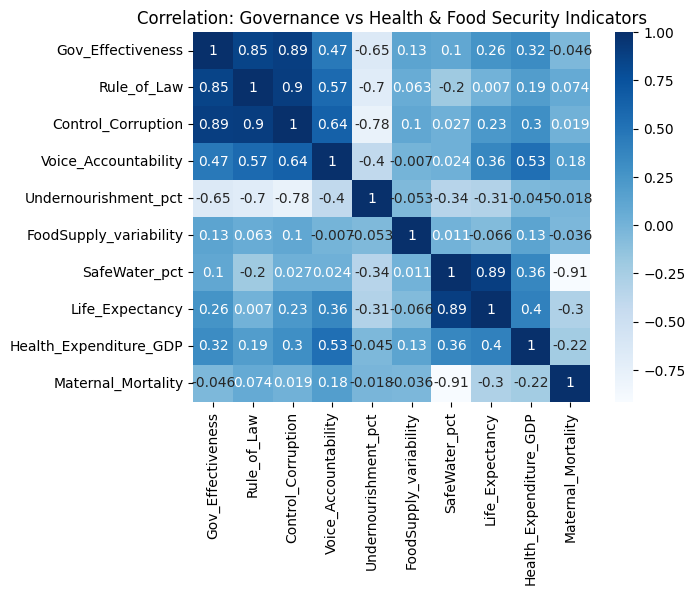

In [8]:

corr = df[['Gov_Effectiveness', 'Rule_of_Law', 'Control_Corruption',
    'Voice_Accountability', 'Undernourishment_pct', 'FoodSupply_variability',
    'SafeWater_pct','Life_Expectancy', 'Health_Expenditure_GDP','Maternal_Mortality',]].corr()

sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation: Governance vs Health & Food Security Indicators')
plt.savefig('correlation_matrix.png')


**Governance Indicators are Highly Inter‑Correlated**: The four governance indicators — Gov_Effectiveness, Rule_of_Law, Control_Corruption, Voice_Accountability — are strongly inter-correlated (r = 0.47 to 0.90), confirming they measure aspects of the same underlying construct: institutional quality. This justifies building a Composite Governance Index as a single synthetic variable.

M&E insight: Using all four separately in a regression would create multicollinearity issues — one composite index is both more robust and more interpretable.

**Governance vs Food Security (negative correlations)**: Control of Corruption is the governance dimension most strongly linked to food security (-0.78) — stronger than government effectiveness (-0.65) or rule of law (-0.7). This is a non-trivial and policy-relevant finding.

**Health indicators (strong internal cluster)**: Safe water access is the single strongest predictor of both life expectancy and maternal mortality in this dataset — stronger than health expenditure. This aligns with global evidence.

**Weak/Surprising relationships**: Governance does not directly predict life expectancy or maternal mortality in this dataset — it operates indirectly through food security and water access. This is a classic mediation effect worth exploring.

**Food supply variability** shows almost no correlation with any indicator.

**Health expenditure** is only weakly correlated with maternal mortality (r = –0.22), which is counter‑intuitive and deserves explicit mention.




### Control of Corruption vs Undernourishment — Scatter by Country

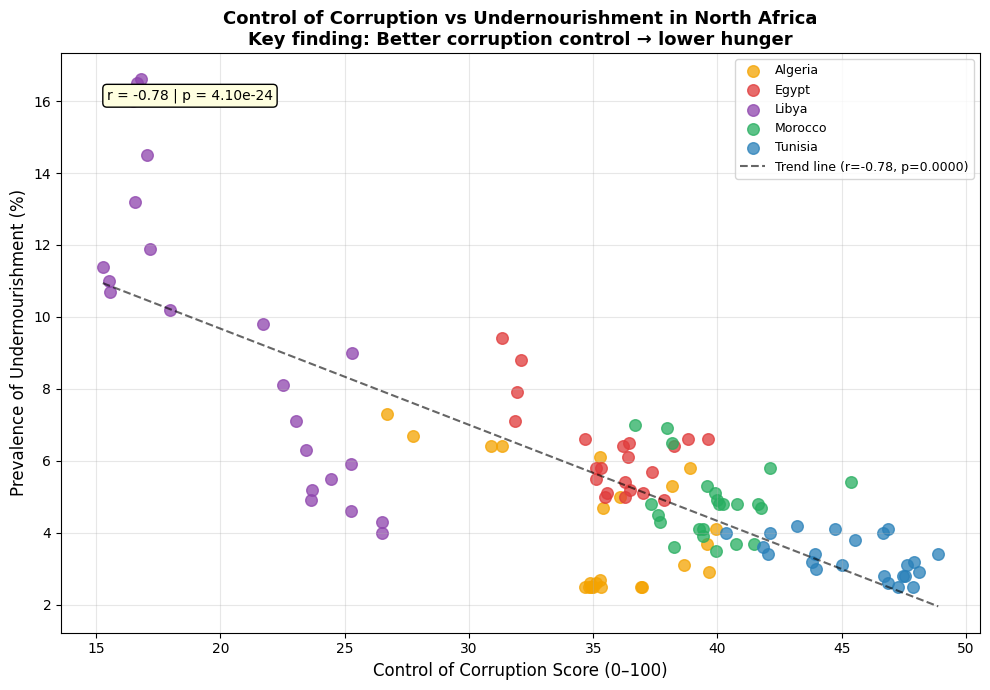

✅ Graph 1 saved


In [9]:

import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import numpy as np
# ============================================================
# SETUP
# ============================================================

df = df.sort_values(['Country', 'Year']).reset_index(drop=True)

colors = {
    'Algeria': '#F4A300',
    'Egypt':   '#E03A3A',
    'Libya':   '#8E44AD',
    'Morocco': '#27AE60',
    'Tunisia': '#2980B9'
}
countries = df['Country'].unique()

# ============================================================
# GRAPH 1 — Control of Corruption vs Undernourishment
# Strongest cross-domain correlation (r = -0.78)
# Key question: Do countries with better corruption control
# feed their people better?
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))

for country in countries:
    sub = df[df['Country'] == country].dropna(
        subset=['Control_Corruption', 'Undernourishment_pct']
    )
    ax.scatter(sub['Control_Corruption'], sub['Undernourishment_pct'],
               color=colors[country], label=country, alpha=0.75, s=70)

# Global trend line
valid = df[['Control_Corruption', 'Undernourishment_pct']].dropna()
m, b, r, p, _ = stats.linregress(
    valid['Control_Corruption'], valid['Undernourishment_pct']
)
x_line = np.linspace(valid['Control_Corruption'].min(),
                     valid['Control_Corruption'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', alpha=0.6,
        label=f'Trend line (r={r:.2f}, p={p:.4f})')

ax.set_xlabel('Control of Corruption Score (0–100)', fontsize=12)
ax.set_ylabel('Prevalence of Undernourishment (%)', fontsize=12)
ax.set_title(
    'Control of Corruption vs Undernourishment in North Africa\n'
    'Key finding: Better corruption control → lower hunger',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Annotation
ax.annotate(f'r = {r:.2f} | p = {p:.2e}',
            xy=(0.05, 0.92), xycoords='axes fraction',
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

plt.tight_layout()
plt.savefig('graph1_corruption_vs_undernourishment.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 1 saved")



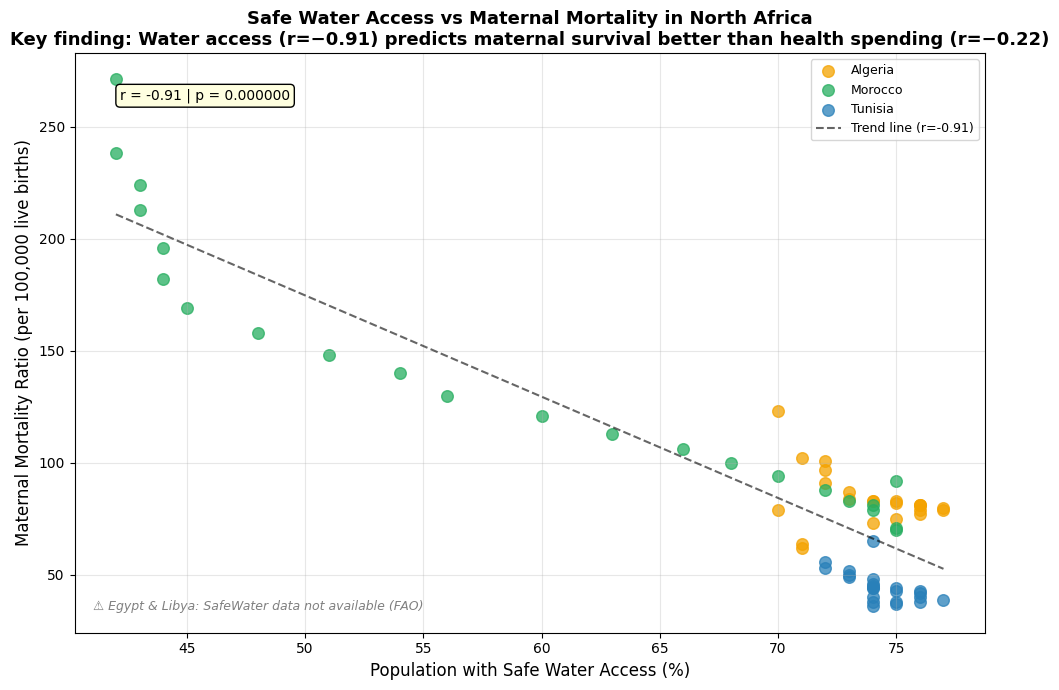

✅ Graph 2 saved


In [10]:
# ============================================================
# GRAPH 2 — Safe Water Access vs Maternal Mortality
# Strongest relationship in the matrix (r = -0.91)
# Key question: Is safe water the most powerful predictor
# of maternal survival?
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))

for country in countries:
    sub = df[df['Country'] == country].dropna(
        subset=['SafeWater_pct', 'Maternal_Mortality']
    )
    if len(sub) > 0:
        sc = ax.scatter(sub['SafeWater_pct'], sub['Maternal_Mortality'],
                        color=colors[country], label=country,
                        alpha=0.75, s=70)

# Trend line
valid = df[['SafeWater_pct', 'Maternal_Mortality']].dropna()
m, b, r, p, _ = stats.linregress(
    valid['SafeWater_pct'], valid['Maternal_Mortality']
)
x_line = np.linspace(valid['SafeWater_pct'].min(),
                     valid['SafeWater_pct'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', alpha=0.6,
        label=f'Trend line (r={r:.2f})')

ax.set_xlabel('Population with Safe Water Access (%)', fontsize=12)
ax.set_ylabel('Maternal Mortality Ratio (per 100,000 live births)',
              fontsize=12)
ax.set_title(
    'Safe Water Access vs Maternal Mortality in North Africa\n'
    'Key finding: Water access (r=−0.91) predicts maternal survival '
    'better than health spending (r=−0.22)',
    fontsize=13, fontweight='bold'
)

# Note about missing data
ax.annotate('⚠️ Egypt & Libya: SafeWater data not available (FAO)',
            xy=(0.02, 0.04), xycoords='axes fraction',
            fontsize=9, color='gray', style='italic')
ax.annotate(f'r = {r:.2f} | p = {p:.6f}',
            xy=(0.05, 0.92), xycoords='axes fraction',
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graph2_safewater_vs_maternal_mortality.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 2 saved")



- This scatter plot shows a very clear message: safe water access is strongly linked to maternal survival in North Africa.
- Country patterns: Algeria, Morocco, and Tunisia all follow the same trend — countries with higher safe water coverage have much lower maternal mortality ratios.
- Data gaps: Egypt and Libya are excluded due to missing safe water data, but the pattern among the other three countries is already very strong.



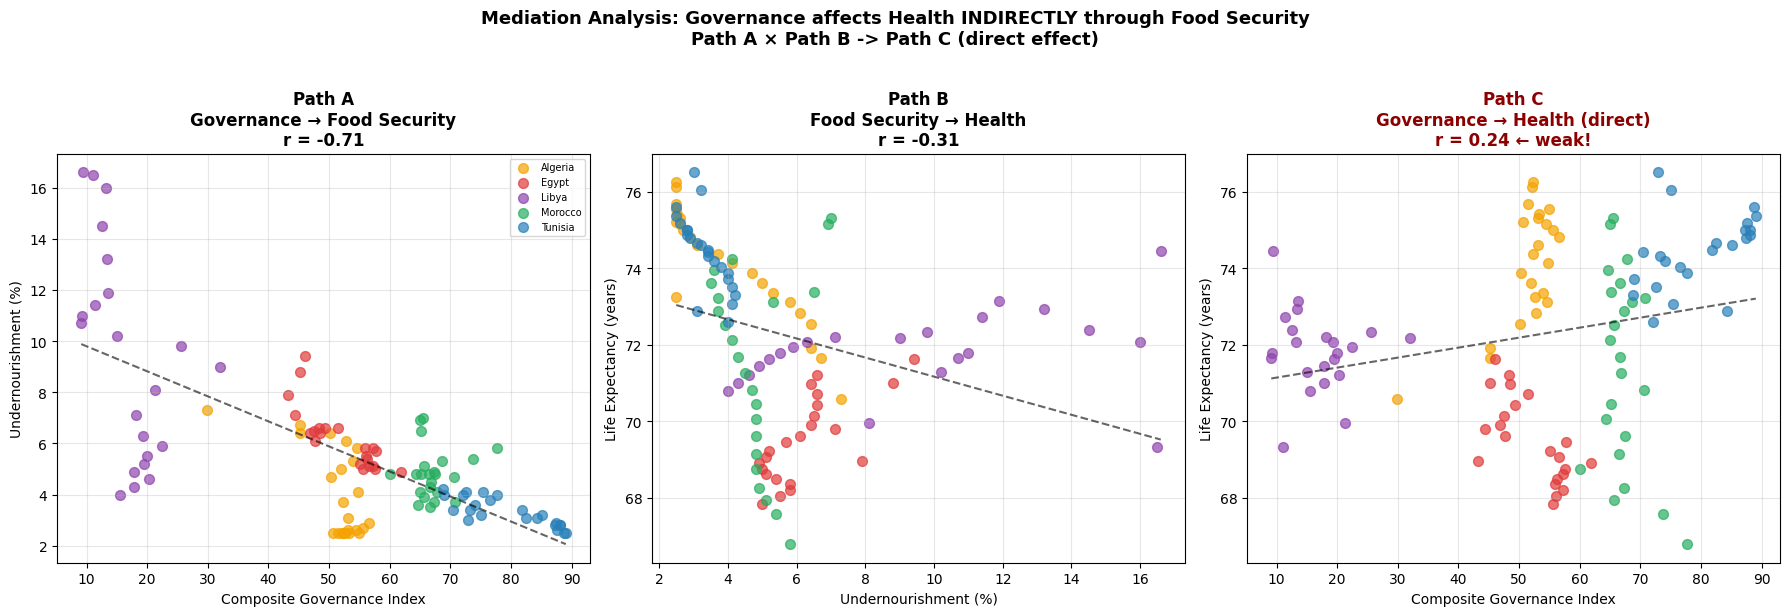

✅ Graph 3 saved


In [11]:
# ============================================================
# GRAPH 3 — Mediation Pathway
# Governance → Food Security → Health
# Key question: Does governance affect health INDIRECTLY
# through food security?
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# Build Composite Governance Index
gov_cols = ['Gov_Effectiveness', 'Rule_of_Law',
            'Control_Corruption', 'Voice_Accountability']
scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[gov_cols] = scaler.fit_transform(df[gov_cols].fillna(df[gov_cols].mean()))
df['Governance_Index'] = df_norm[gov_cols].mean(axis=1) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Path A: Governance → Undernourishment
valid_a = df[['Governance_Index', 'Undernourishment_pct']].dropna()
m_a, b_a, r_a, p_a, _ = stats.linregress(
    valid_a['Governance_Index'], valid_a['Undernourishment_pct']
)
for country in countries:
    sub = df[df['Country'] == country].dropna(
        subset=['Governance_Index', 'Undernourishment_pct']
    )
    axes[0].scatter(sub['Governance_Index'], sub['Undernourishment_pct'],
                    color=colors[country], alpha=0.7, s=50, label=country)
x_a = np.linspace(valid_a['Governance_Index'].min(),
                  valid_a['Governance_Index'].max(), 100)
axes[0].plot(x_a, m_a * x_a + b_a, 'k--', alpha=0.6)
axes[0].set_xlabel('Composite Governance Index', fontsize=10)
axes[0].set_ylabel('Undernourishment (%)', fontsize=10)
axes[0].set_title(f'Path A\nGovernance → Food Security\nr = {r_a:.2f}',
                  fontweight='bold')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

# Path B: Undernourishment → Life Expectancy
valid_b = df[['Undernourishment_pct', 'Life_Expectancy']].dropna()
m_b, b_b, r_b, p_b, _ = stats.linregress(
    valid_b['Undernourishment_pct'], valid_b['Life_Expectancy']
)
for country in countries:
    sub = df[df['Country'] == country].dropna(
        subset=['Undernourishment_pct', 'Life_Expectancy']
    )
    axes[1].scatter(sub['Undernourishment_pct'], sub['Life_Expectancy'],
                    color=colors[country], alpha=0.7, s=50)
x_b = np.linspace(valid_b['Undernourishment_pct'].min(),
                  valid_b['Undernourishment_pct'].max(), 100)
axes[1].plot(x_b, m_b * x_b + b_b, 'k--', alpha=0.6)
axes[1].set_xlabel('Undernourishment (%)', fontsize=10)
axes[1].set_ylabel('Life Expectancy (years)', fontsize=10)
axes[1].set_title(f'Path B\nFood Security → Health\nr = {r_b:.2f}',
                  fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Path C: Governance → Life Expectancy (direct — weak)
valid_c = df[['Governance_Index', 'Life_Expectancy']].dropna()
m_c, b_c, r_c, p_c, _ = stats.linregress(
    valid_c['Governance_Index'], valid_c['Life_Expectancy']
)
for country in countries:
    sub = df[df['Country'] == country].dropna(
        subset=['Governance_Index', 'Life_Expectancy']
    )
    axes[2].scatter(sub['Governance_Index'], sub['Life_Expectancy'],
                    color=colors[country], alpha=0.7, s=50)
x_c = np.linspace(valid_c['Governance_Index'].min(),
                  valid_c['Governance_Index'].max(), 100)
axes[2].plot(x_c, m_c * x_c + b_c, 'k--', alpha=0.6)
axes[2].set_xlabel('Composite Governance Index', fontsize=10)
axes[2].set_ylabel('Life Expectancy (years)', fontsize=10)
axes[2].set_title(f'Path C\nGovernance → Health (direct)\nr = {r_c:.2f} ← weak!',
                  fontweight='bold', color='darkred')
axes[2].grid(True, alpha=0.3)

fig.suptitle(
    'Mediation Analysis: Governance affects Health INDIRECTLY through Food Security\n'
    'Path A × Path B -> Path C (direct effect)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('graph3_mediation_governance_health.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 3 saved")



- Governance reduces undernourishment (Path A).
- Undernourishment reduces life expectancy (Path B).
- The direct effect of governance on health (Path C) is weak.
- Therefore, governance improves health mainly through its impact on food security, not directly.


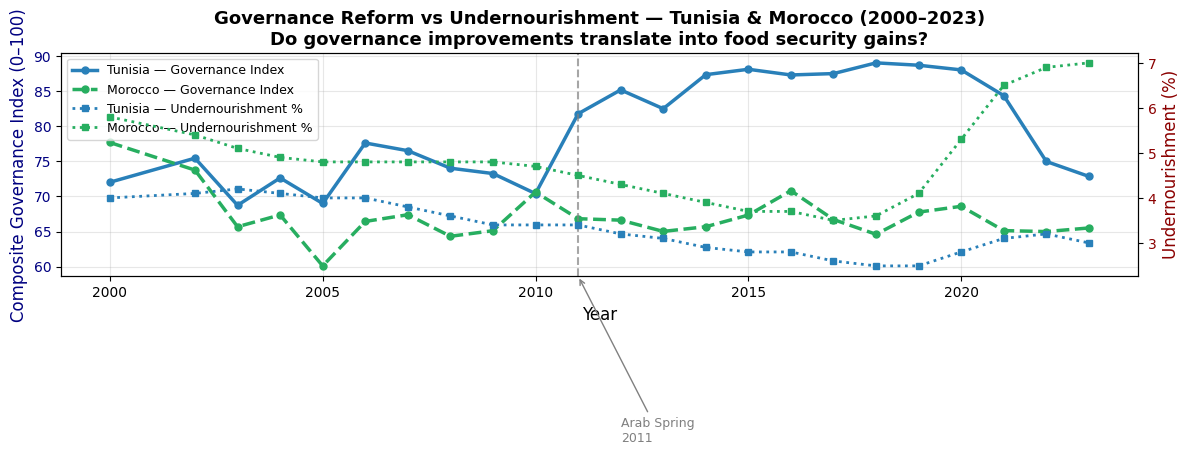

✅ Graph 4 saved


In [12]:
# ============================================================
# GRAPH 4 — Composite Governance Index vs Undernourishment
# Time series overlay for Tunisia and Morocco
# Key question: Does governance reform reduce hunger over time?
# ============================================================
focus_countries = ['Tunisia', 'Morocco']

fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()

line_styles = {'Tunisia': '-', 'Morocco': '--'}

for country in focus_countries:
    sub = df[df['Country'] == country].dropna(
        subset=['Governance_Index', 'Undernourishment_pct']
    ).sort_values('Year')

    ax1.plot(sub['Year'], sub['Governance_Index'],
             color=colors[country], linestyle=line_styles[country],
             linewidth=2.5, marker='o', markersize=5,
             label=f'{country} — Governance Index')
    ax2.plot(sub['Year'], sub['Undernourishment_pct'],
             color=colors[country], linestyle=':',
             linewidth=2, marker='s', markersize=5,
             label=f'{country} — Undernourishment %')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Composite Governance Index (0–100)',
               fontsize=12, color='navy')
ax2.set_ylabel('Undernourishment (%)', fontsize=12, color='darkred')
ax1.tick_params(axis='y', labelcolor='navy')
ax2.tick_params(axis='y', labelcolor='darkred')

ax1.axvline(x=2011, color='gray', linestyle='--', alpha=0.7)
ax1.annotate('Arab Spring\n2011', xy=(2011, ax1.get_ylim()[0]),
             xytext=(2012, 35), fontsize=9, color='gray',
             arrowprops=dict(arrowstyle='->', color='gray'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=9)

ax1.set_title(
    'Governance Reform vs Undernourishment — Tunisia & Morocco (2000–2023)\n'
    'Do governance improvements translate into food security gains?',
    fontsize=13, fontweight='bold'
)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graph4_governance_vs_hunger_timeseries.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 4 saved")



- Governance improvements in Tunisia appear to be linked with reductions in undernourishment, supporting the idea that better governance can strengthen food security.
- Morocco shows food security gains even when governance improvements are gradual and moderate, but also that it can be fragile when external pressures arise (2020).
- The comparison underscores that governance is an important driver, but not the only factor — economic resilience, social policies, and external shocks also matter.

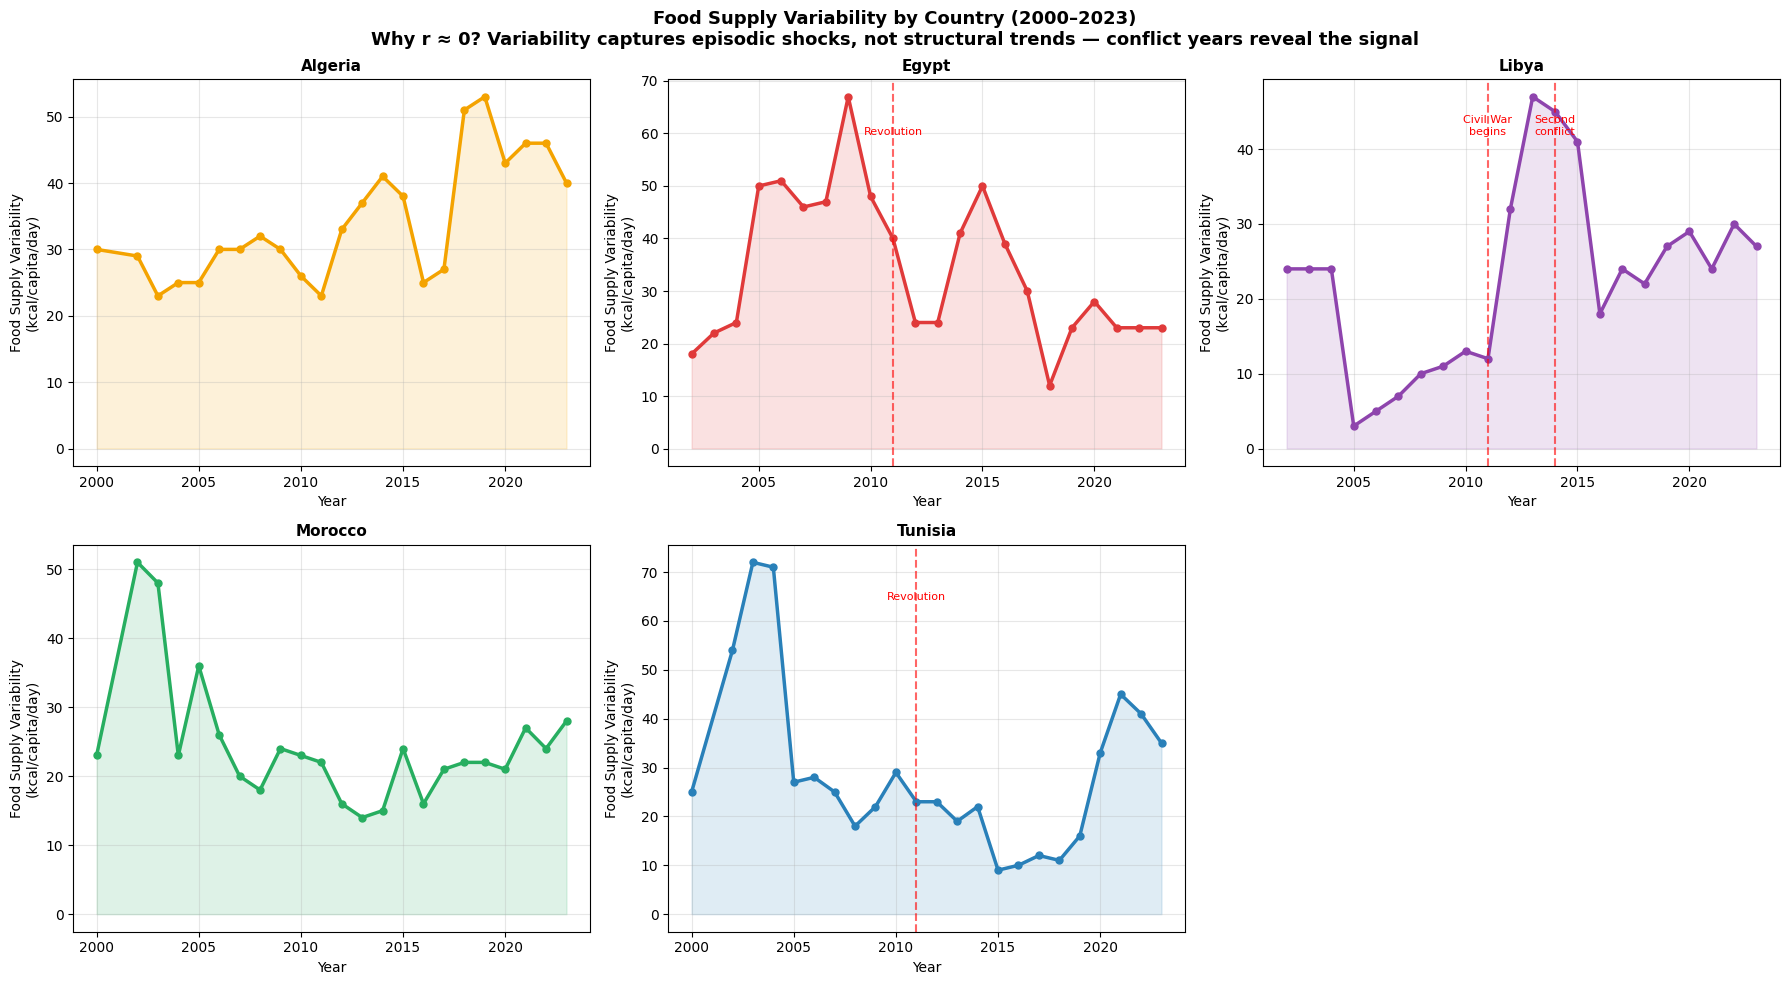

✅ Graph 5 saved


In [13]:
# ============================================================
# GRAPH 5 — FoodSupply_variability over time
# Why does it correlate with nothing?
# Key question: Does variability spike during conflict years?
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

conflict_events = {
    'Libya': [(2011, 'Civil War\nbegins'),
              (2014, 'Second\nconflict')],
    'Egypt': [(2011, 'Revolution')],
    'Tunisia': [(2011, 'Revolution')]
}

for i, country in enumerate(countries):
    sub = df[df['Country'] == country].sort_values('Year')
    ax = axes[i]
    ax.plot(sub['Year'], sub['FoodSupply_variability'],
            color=colors[country], linewidth=2.5,
            marker='o', markersize=5)
    ax.fill_between(sub['Year'], sub['FoodSupply_variability'],
                    alpha=0.15, color=colors[country])

    # Conflict annotations
    if country in conflict_events:
        for yr, label in conflict_events[country]:
            ax.axvline(x=yr, color='red', linestyle='--', alpha=0.6)
            ax.annotate(label, xy=(yr, ax.get_ylim()[1] * 0.85),
                        fontsize=8, color='red', ha='center')

    ax.set_title(f'{country}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Food Supply Variability\n(kcal/capita/day)')
    ax.grid(True, alpha=0.3)

# Remove empty subplot
axes[-1].axis('off')

fig.suptitle(
    'Food Supply Variability by Country (2000–2023)\n'
    'Why r ≈ 0? Variability captures episodic shocks, '
    'not structural trends — conflict years reveal the signal',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('graph5_foodsupply_variability_conflict.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 5 saved")




- Algeria → Structural fragility: Steady rise in variability since 2015, reflecting growing import dependency. No conflict shocks, but a worrying upward trend.
- Egypt → Economic adjustment: Dramatic spike in 2008–2010 (global food price crisis + pre‑revolution instability), followed by sharp decline post‑2011 and stabilization by 2020.
- Libya → Conflict disruption: Two clear spikes (2011 Civil War, 2014 conflict) — textbook evidence that armed conflict destabilizes food supply.
- Morocco → Modernization success: High variability before 2005 due to drought‑sensitive agriculture, then sustained improvement under the Green Morocco Plan.
- Tunisia → Paradoxical trajectory: Unexpected drop after the 2011 Revolution, then dramatic spike post‑2019 amid political‑economic crisis — the most analytically intriguing case.
Key finding: FoodSupply_variability r≈0 globally because it captures episodic shocks, not structural trends. 



C:\Users\abouf\AppData\Local\Temp\ipykernel_17592\2778315675.py:46: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\abouf\AppData\Local\Temp\ipykernel_17592\2778315675.py:46: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\abouf\AppData\Local\Temp\ipykernel_17592\2778315675.py:47: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('graph6_health_expenditure_vs_maternal_country.png',
C:\Users\abouf\AppData\Local\Temp\ipykernel_17592\2778315675.py:47: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('graph6_health_expenditure_vs_maternal_country.png',
C:\Users\abouf\anaconda3\envs\RP_Env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\abouf\anacon

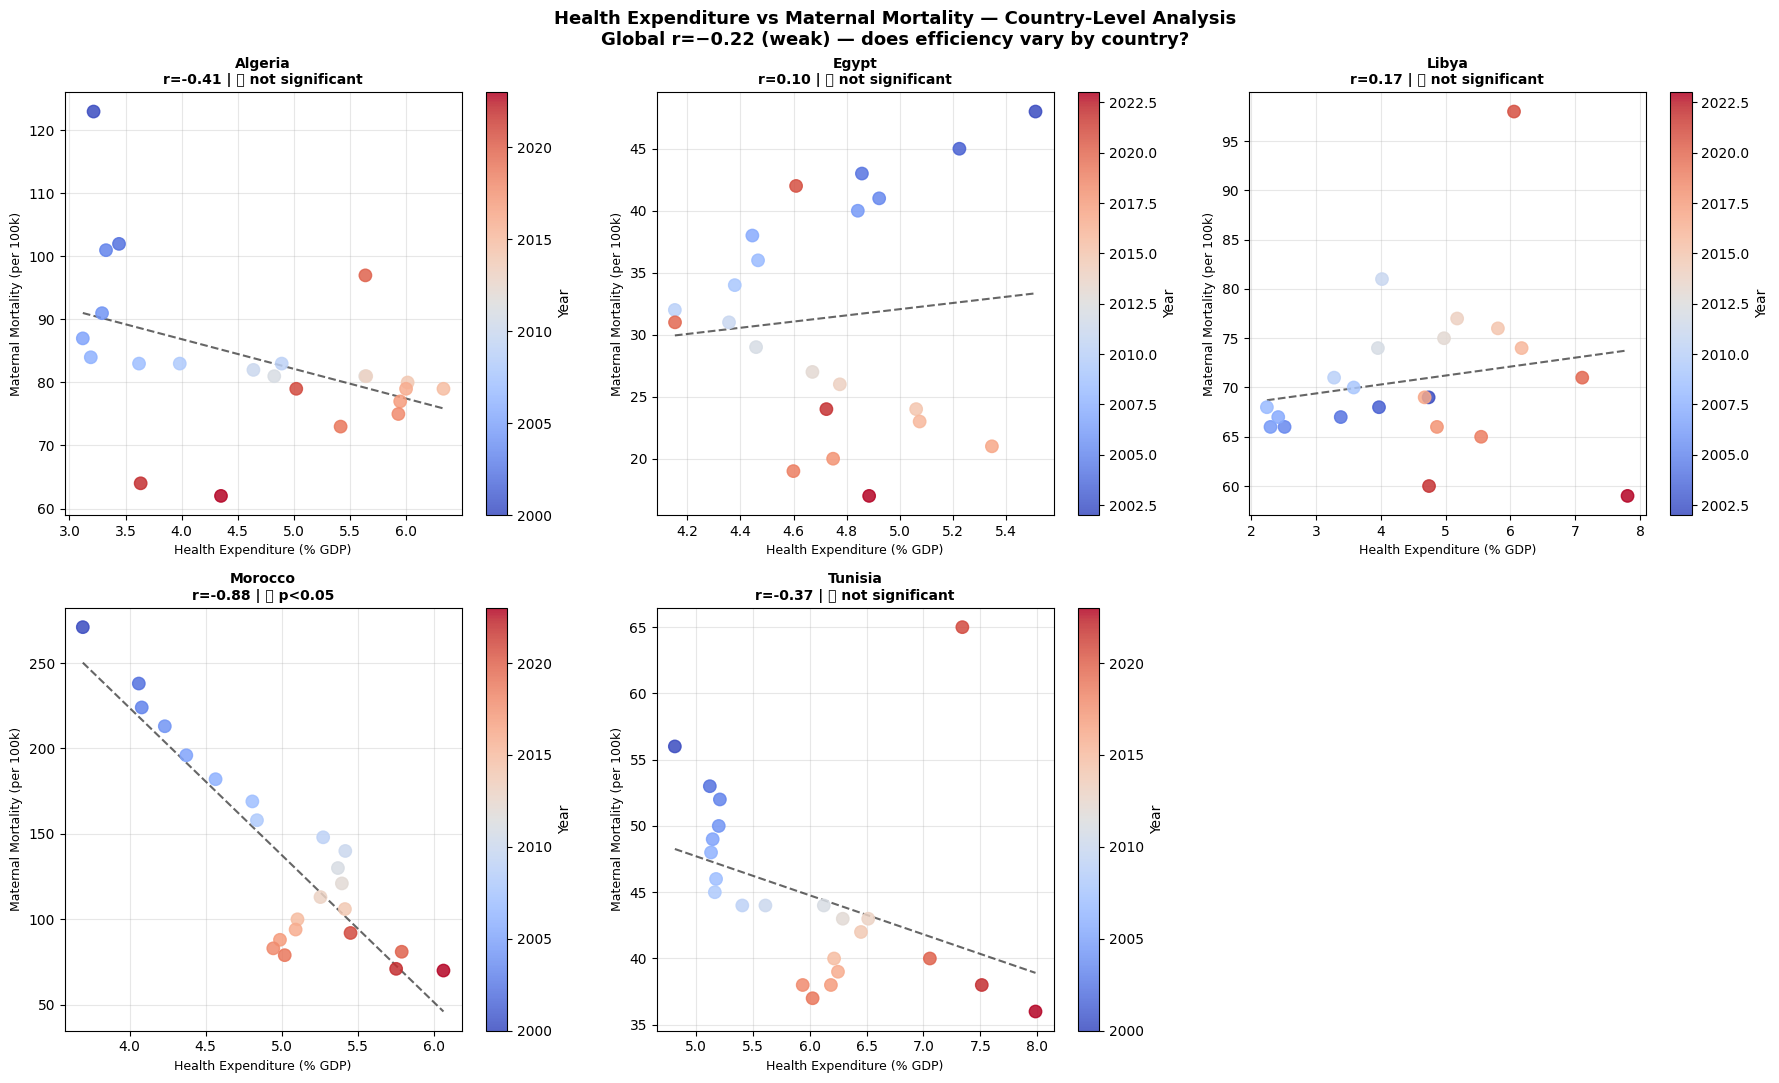

✅ Graph 6 saved


In [14]:
# ============================================================
# GRAPH 6 — Health Expenditure vs Maternal Mortality
# By country — does spending efficiency differ?
# Key question: Does more spending reduce maternal deaths
# equally across countries?
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, country in enumerate(countries):
    sub = df[df['Country'] == country].dropna(
        subset=['Health_Expenditure_GDP', 'Maternal_Mortality']
    )
    ax = axes[i]
    sc = ax.scatter(sub['Health_Expenditure_GDP'],
                    sub['Maternal_Mortality'],
                    c=sub['Year'], cmap='coolwarm',
                    s=80, alpha=0.85, zorder=3)

    # Country-level regression
    if len(sub) > 3:
        m, b, r, p, _ = stats.linregress(
            sub['Health_Expenditure_GDP'], sub['Maternal_Mortality']
        )
        x_r = np.linspace(sub['Health_Expenditure_GDP'].min(),
                          sub['Health_Expenditure_GDP'].max(), 100)
        ax.plot(x_r, m * x_r + b, 'k--', alpha=0.6, linewidth=1.5)
        sig = '✅ p<0.05' if p < 0.05 else '❌ not significant'
        ax.set_title(f'{country}\nr={r:.2f} | {sig}',
                     fontweight='bold', fontsize=10)
    else:
        ax.set_title(f'{country}\n(insufficient data)',
                     fontweight='bold', fontsize=10)

    plt.colorbar(sc, ax=ax, label='Year')
    ax.set_xlabel('Health Expenditure (% GDP)', fontsize=9)
    ax.set_ylabel('Maternal Mortality (per 100k)', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')
fig.suptitle(
    'Health Expenditure vs Maternal Mortality — Country-Level Analysis\n'
    'Global r=−0.22 (weak) — does efficiency vary by country?',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('graph6_health_expenditure_vs_maternal_country.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 6 saved")



- The only significant relationship between health expenditure and maternal mortality is observed in Morocco. We already noted that Morocco achieved the steepest improvement in life expectancy (+9 years over 23 years) — an impressive gain that can partly be explained by higher health expenditure.

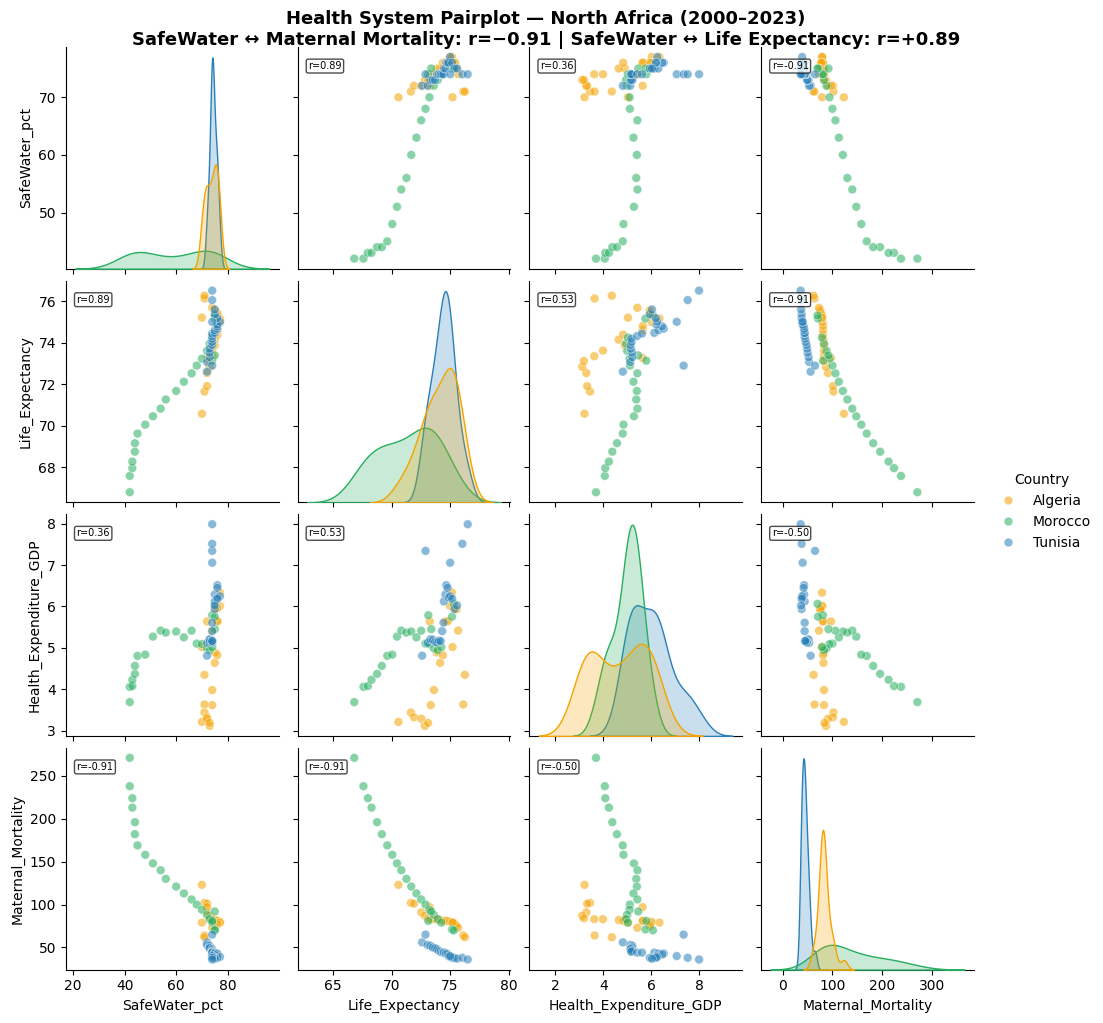

✅ Graph 7 saved

ALL 7 GRAPHS SAVED
  ✅ graph1_corruption_vs_undernourishment.png
  ✅ graph2_safewater_vs_maternal_mortality.png
  ✅ graph3_mediation_governance_health.png
  ✅ graph4_governance_vs_hunger_timeseries.png
  ✅ graph5_foodsupply_variability_conflict.png
  ✅ graph6_health_expenditure_vs_maternal_country.png
  ✅ graph7_pairplot_health_cluster.png


In [15]:
# ============================================================
# GRAPH 7 — Pairplot: Health Cluster
# SafeWater, Life_Expectancy, Maternal_Mortality,
# Health_Expenditure_GDP
# Shows the complete health system picture
# ============================================================
health_vars = [
    'SafeWater_pct', 'Life_Expectancy',
    'Health_Expenditure_GDP', 'Maternal_Mortality'
]

plot_df = df[health_vars + ['Country']].dropna(subset=health_vars)

palette = {c: colors[c] for c in plot_df['Country'].unique()}

g = sns.pairplot(
    plot_df,
    hue='Country',
    diag_kind='kde',
    plot_kws={'alpha': 0.55, 's': 40},
    palette=palette
)

g.figure.suptitle(
    'Health System Pairplot — North Africa (2000–2023)\n'
    'SafeWater ↔ Maternal Mortality: r=−0.91 | '
    'SafeWater ↔ Life Expectancy: r=+0.89',
    y=1.02, fontsize=13, fontweight='bold'
)

# Add correlation annotations on off-diagonal plots
for i, var_y in enumerate(health_vars):
    for j, var_x in enumerate(health_vars):
        if i != j:
            valid = plot_df[[var_x, var_y]].dropna()
            if len(valid) > 5:
                r, p = stats.pearsonr(valid[var_x], valid[var_y])
                g.axes[i][j].annotate(
                    f'r={r:.2f}',
                    xy=(0.05, 0.90), xycoords='axes fraction',
                    fontsize=7, color='black',
                    bbox=dict(boxstyle='round,pad=0.2',
                              facecolor='white', alpha=0.7)
                )

plt.savefig('graph7_pairplot_health_cluster.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph 7 saved")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*55)
print("ALL 7 GRAPHS SAVED")
print("="*55)
graphs = [
    "graph1_corruption_vs_undernourishment.png",
    "graph2_safewater_vs_maternal_mortality.png",
    "graph3_mediation_governance_health.png",
    "graph4_governance_vs_hunger_timeseries.png",
    "graph5_foodsupply_variability_conflict.png",
    "graph6_health_expenditure_vs_maternal_country.png",
    "graph7_pairplot_health_cluster.png"
]
for g in graphs:
    print(f"  ✅ {g}")

- Key finding: Morocco's green dots dominate every scatter plot — its 23-year reform journey is the most visually compelling story in the dataset. Tunisia is the stable high performer. Algeria is the consistent middle performer.

## 3. Analysis of Distributions by Country — Comparative Boxplots

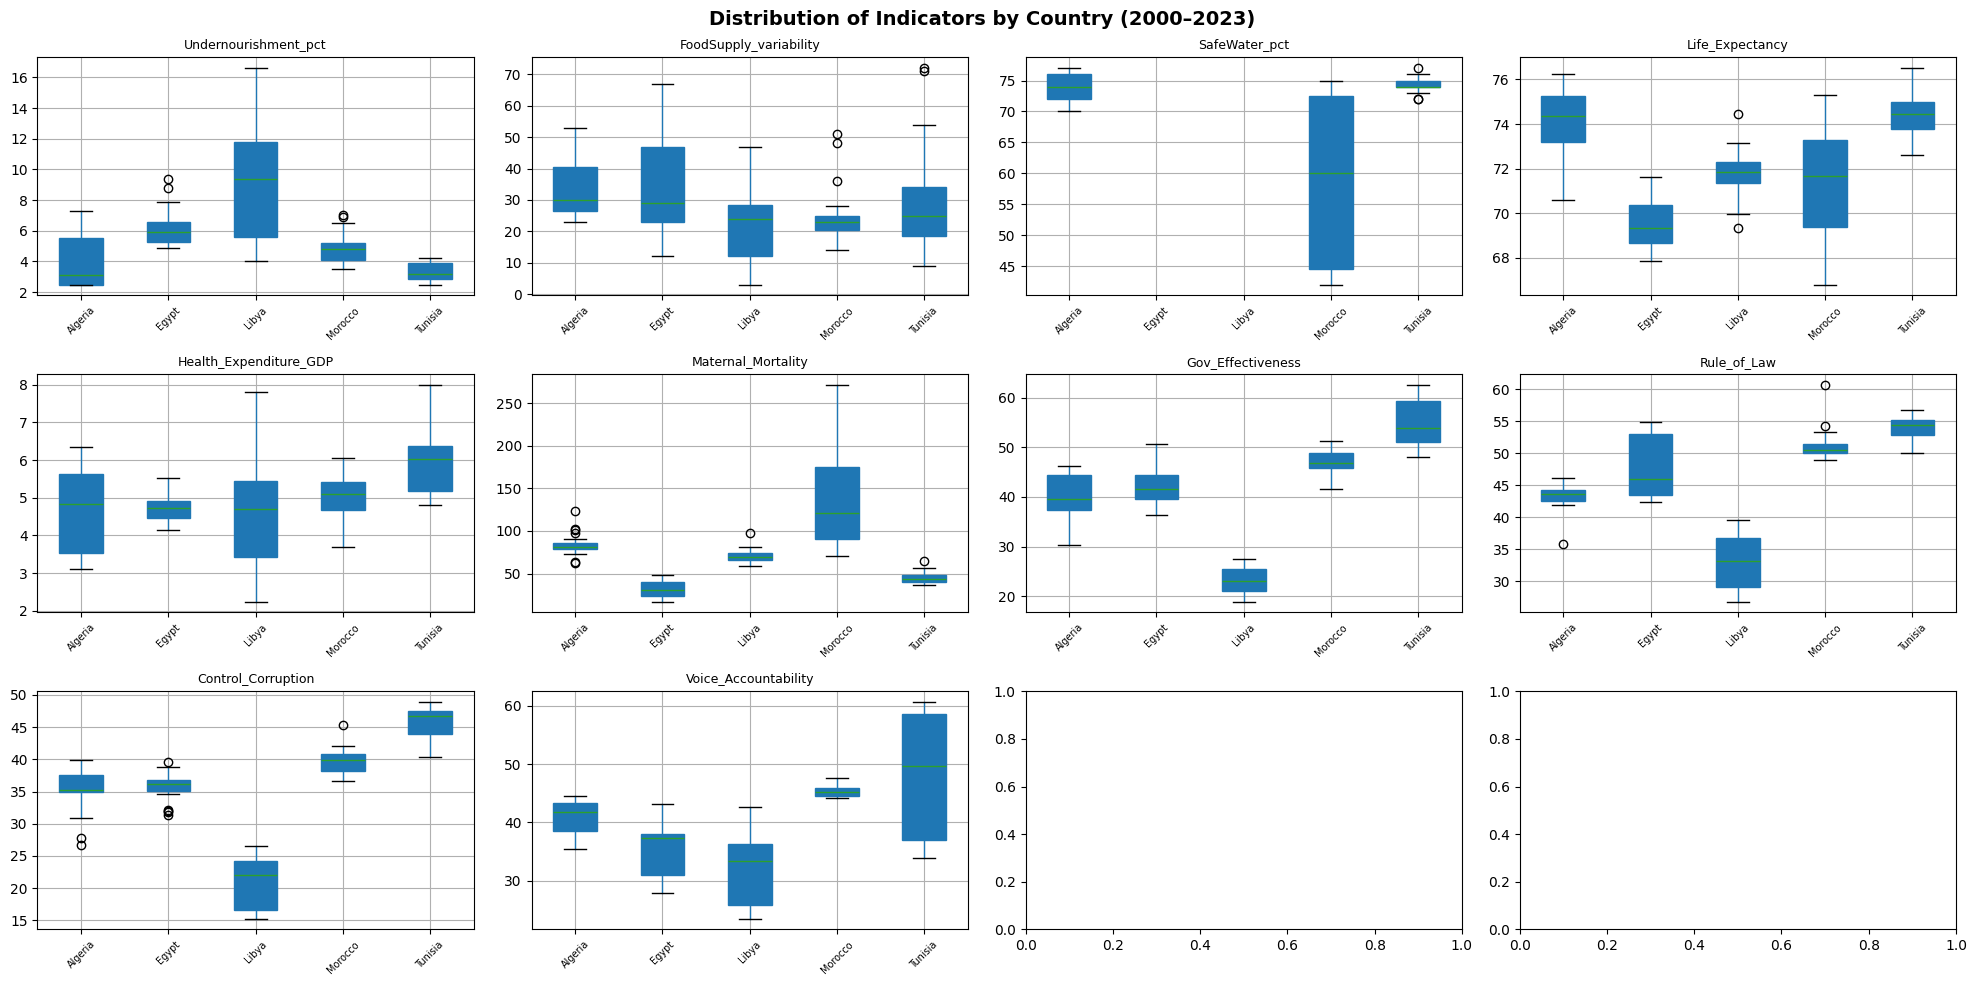

In [17]:

# ── Comparative boxplots by country ──
indicators = [
    'Undernourishment_pct', 'FoodSupply_variability',
    'SafeWater_pct', 'Life_Expectancy',
    'Health_Expenditure_GDP', 'Maternal_Mortality',
    'Gov_Effectiveness', 'Rule_of_Law',
    'Control_Corruption', 'Voice_Accountability'
]

fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(indicators):
    df.boxplot(column=col, by='Country', ax=axes[i],
               patch_artist=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('Distribution of Indicators by Country (2000–2023)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

The comparative boxplots highlight systematic disparities across North African countries. Stronger governance (Tunisia, Morocco) aligns with better health and food security outcomes, while weaker governance and instability (Libya, Egypt, Algeria) correlate with higher volatility and less favorable distributions. This reinforces governance as a critical driver of sustainable development outcomes.

| Country | Governance | Health | Food Security | Overall Profile |
|---------|-----------|--------|---------------|-----------------|
| Tunisia | High, declining | Best | Best | Deteriorating leader |
| Morocco | Improving | Strong | Improving | Rising performer |
| Algeria | Stagnant | Medium | Medium | Stable underperformer |
| Egypt | Declining | Medium | Medium | Authoritarian trajectory |
| Libya | Collapsed | Volatile | Volatile | Conflict-affected |

## 4. Temporal Analysis of Breakpoints — Arab Spring 2011

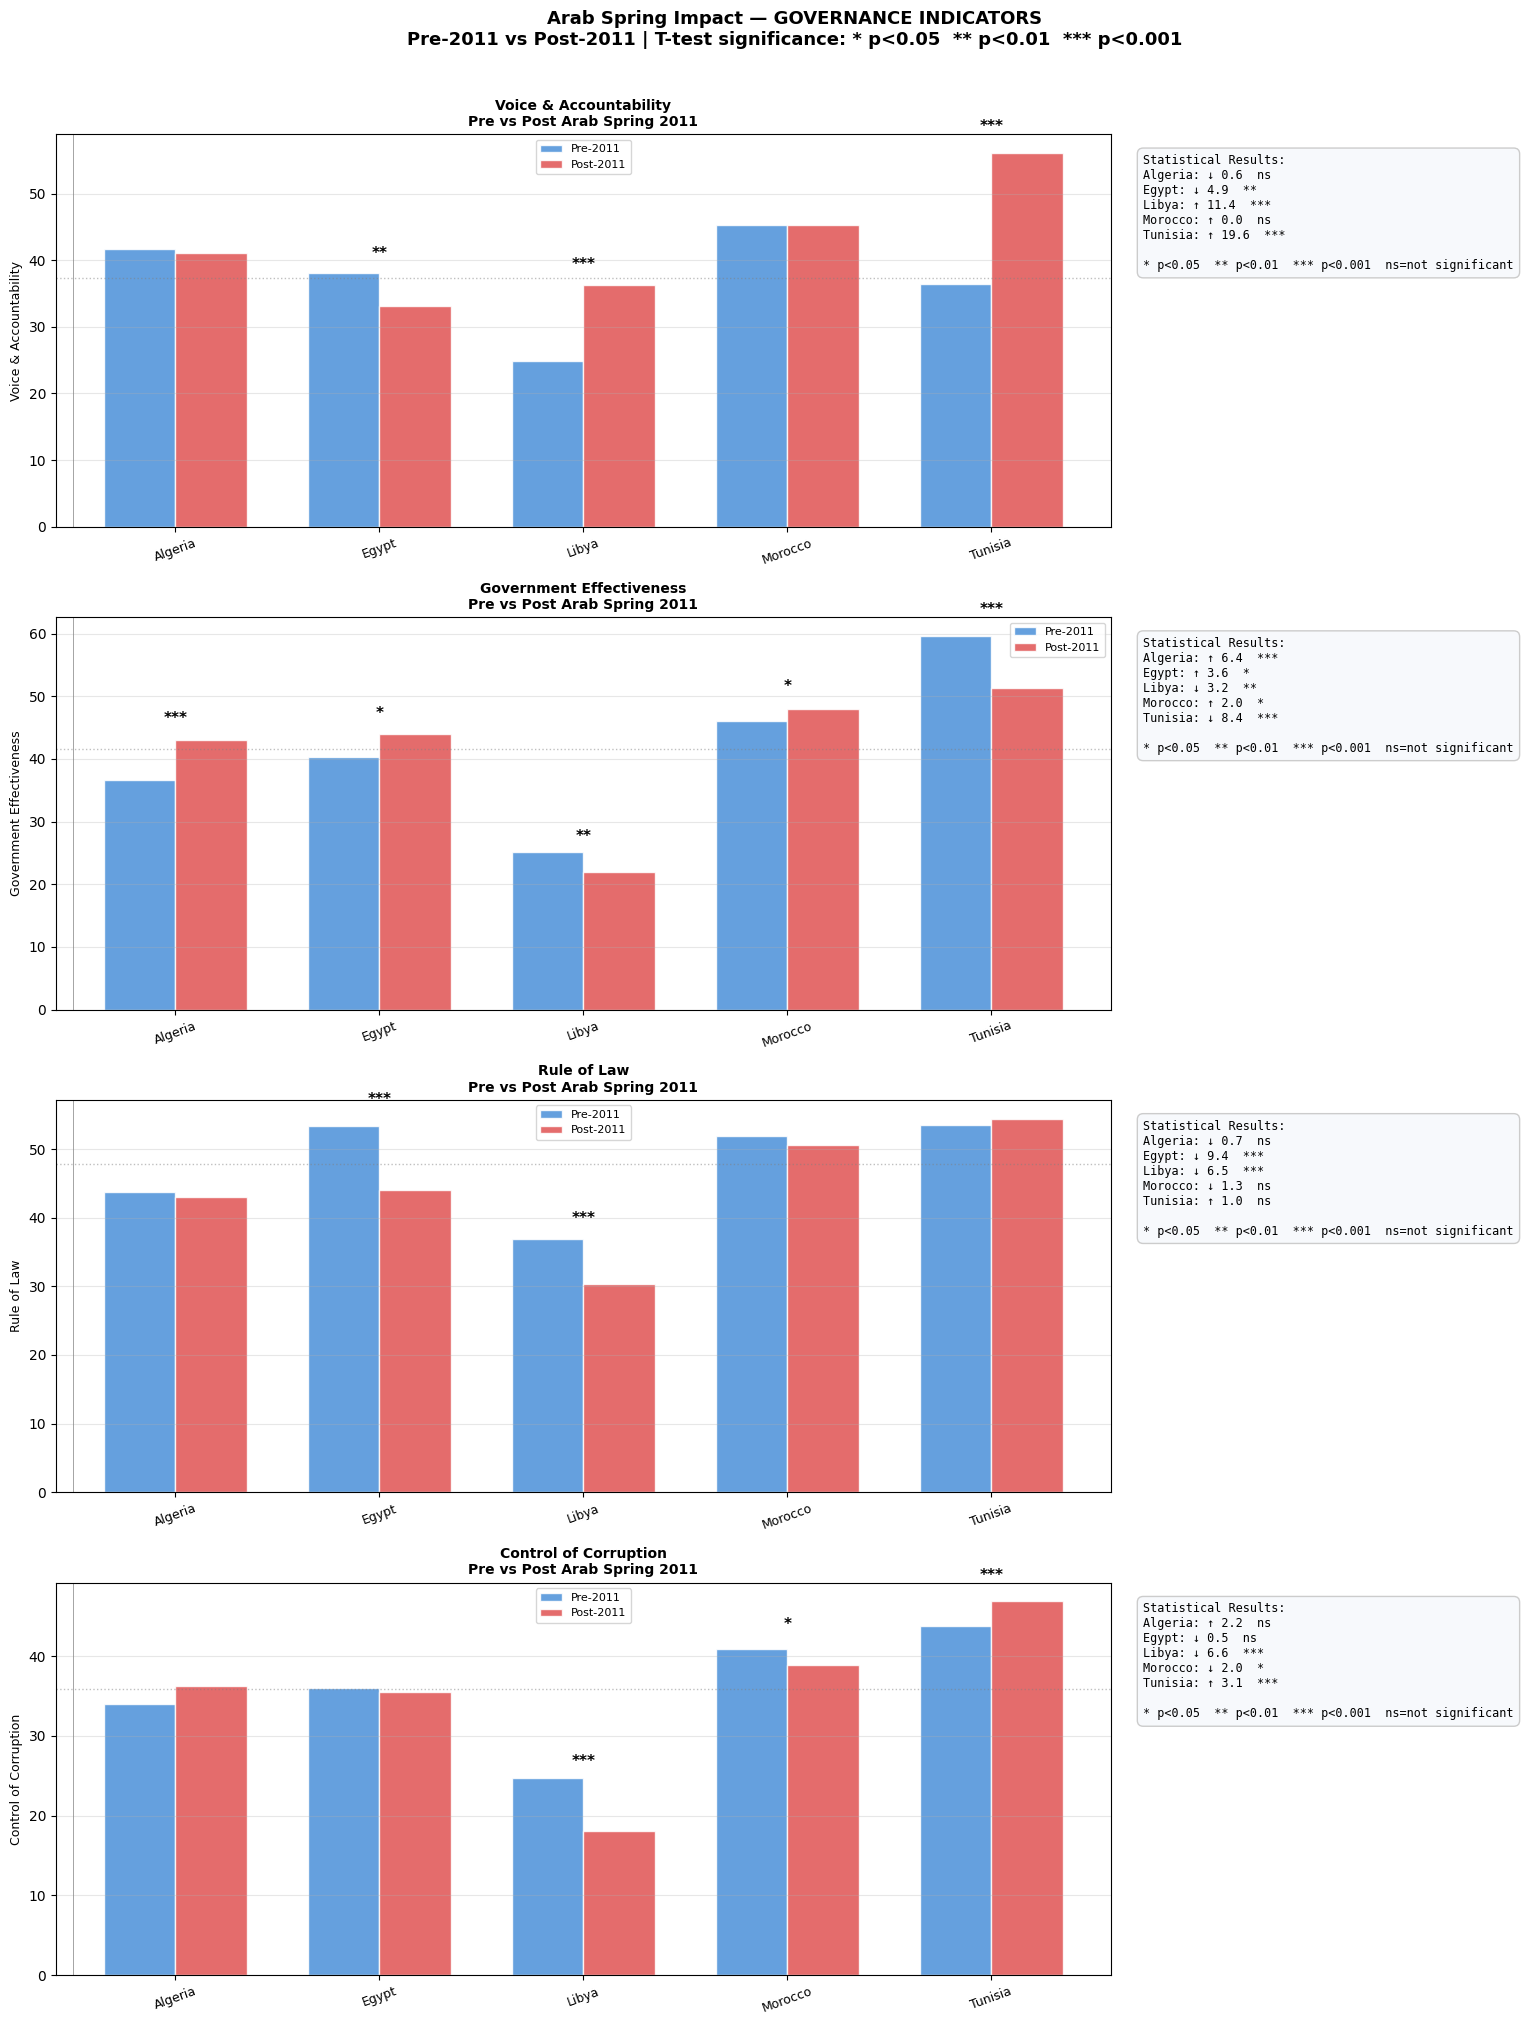

✅ Saved: arab_spring_governance.png


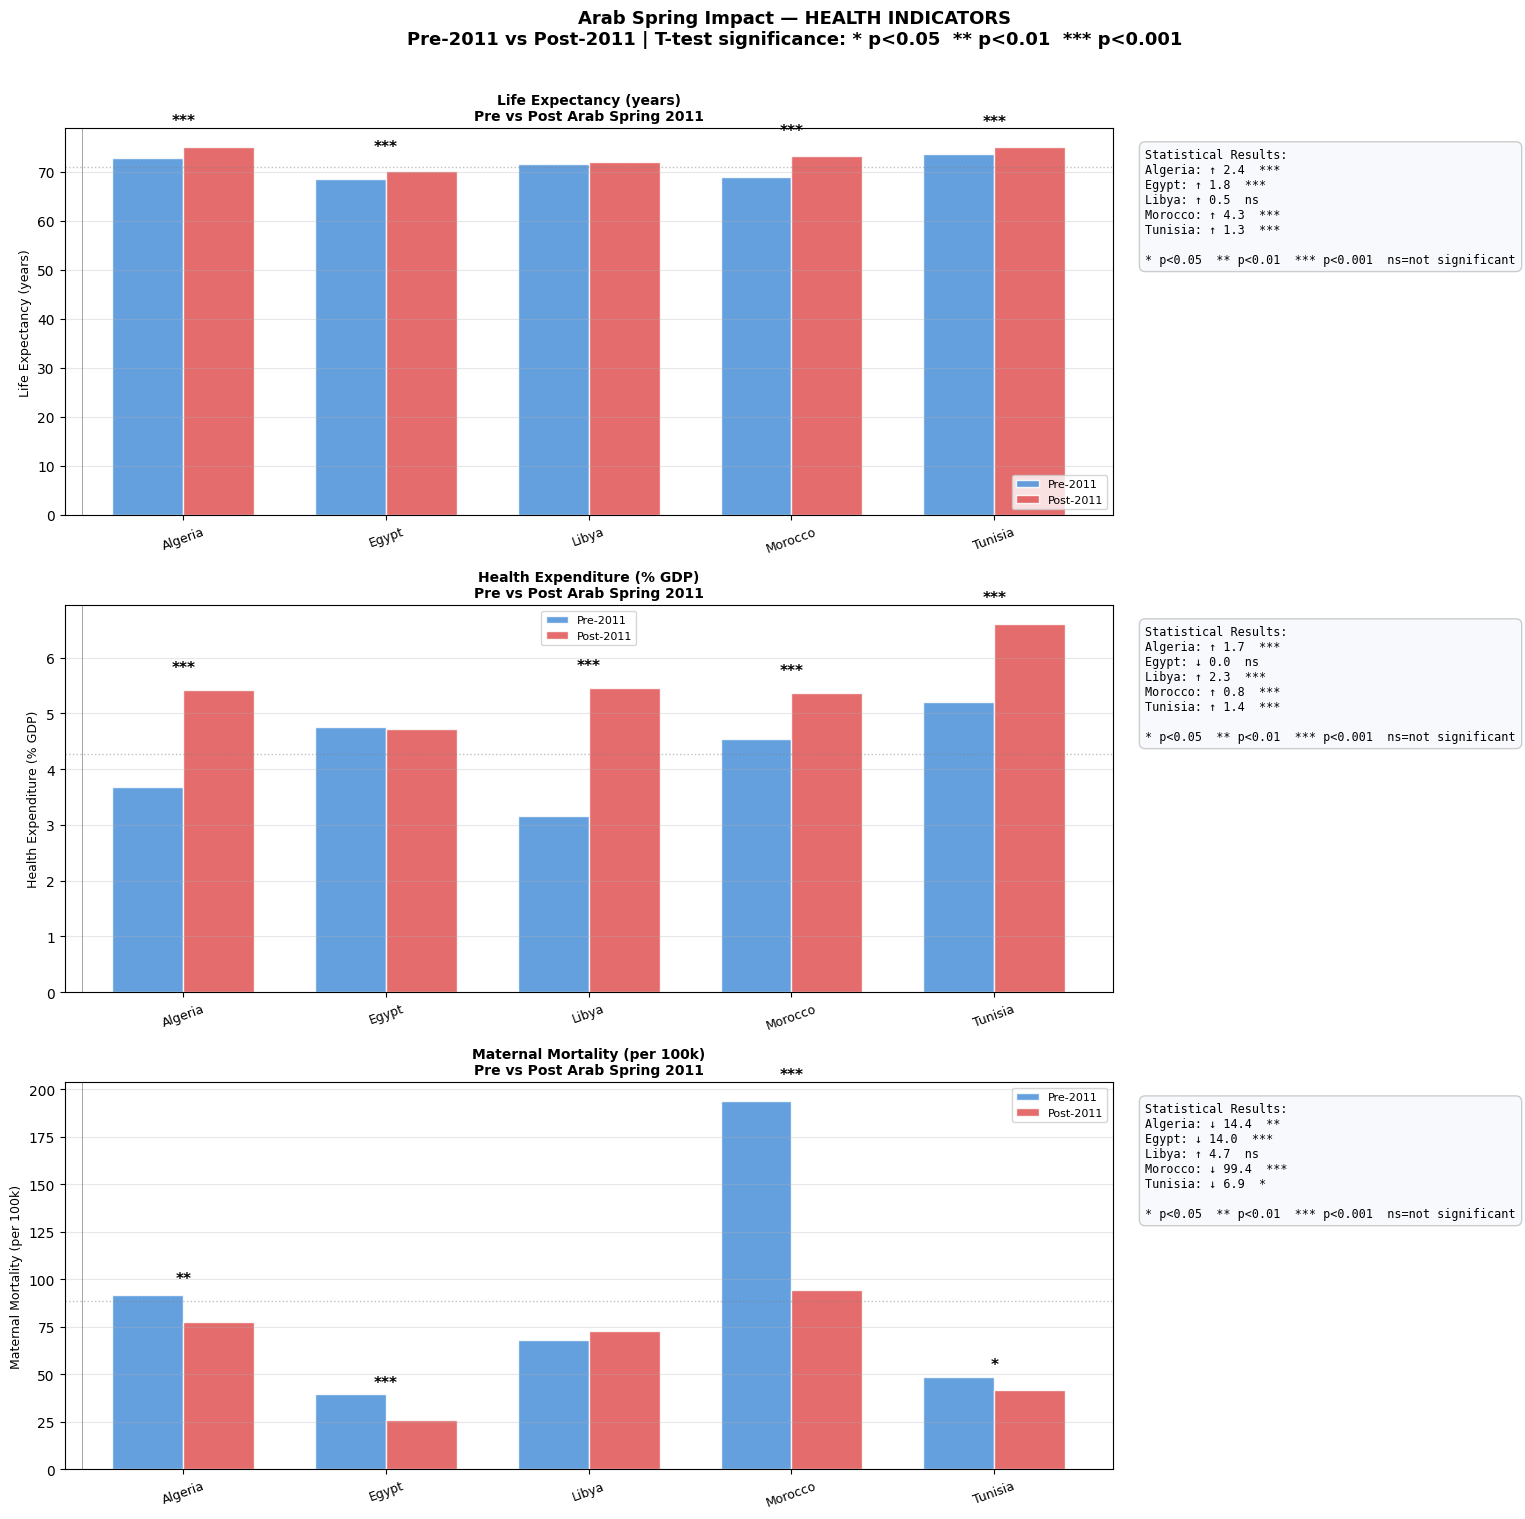

✅ Saved: arab_spring_health.png


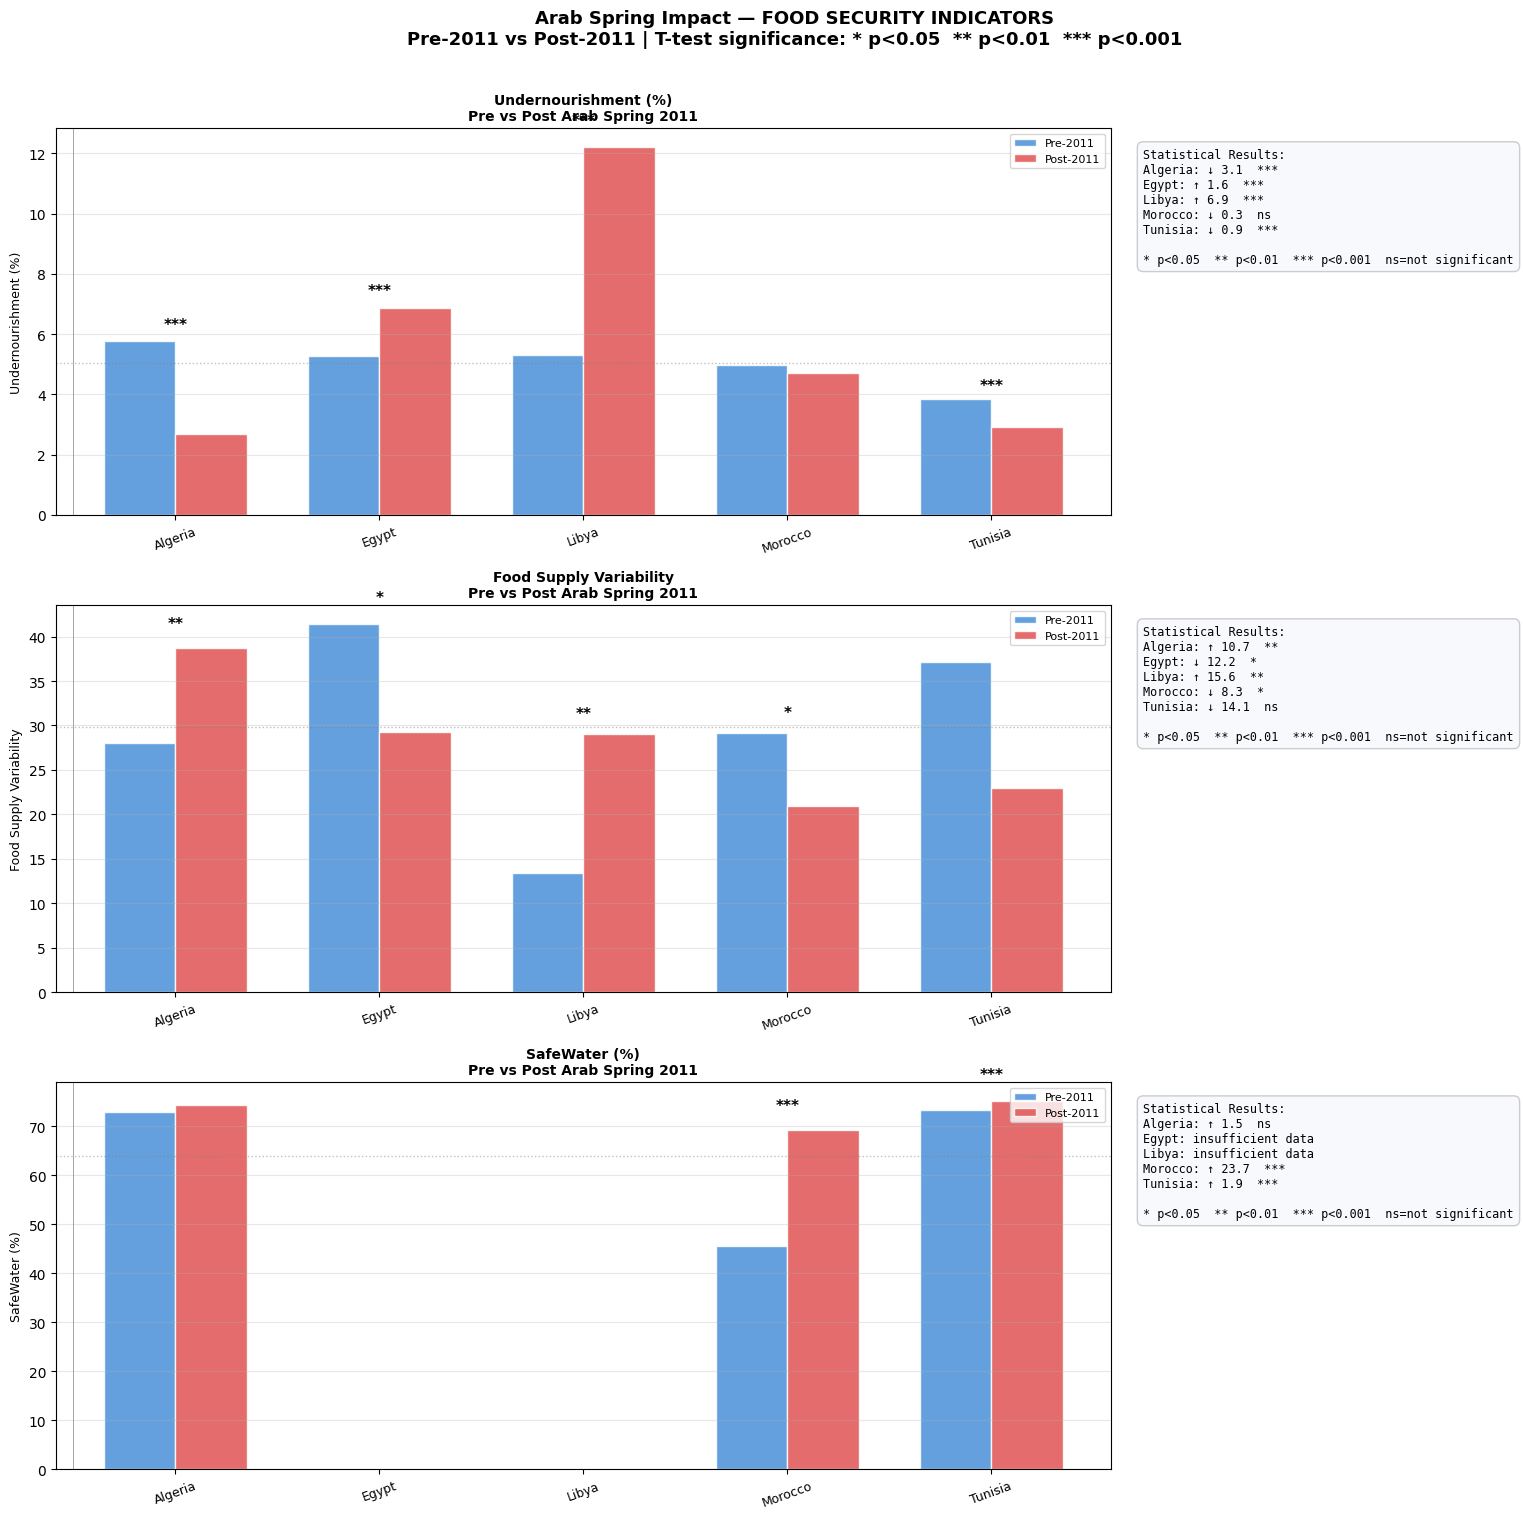

✅ Saved: arab_spring_food.png


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('north_africa_final_clean.csv')
df = df.sort_values(['Country', 'Year']).reset_index(drop=True)

# ============================================================
# DEFINE ALL INDICATORS TO TEST
# ============================================================
indicators_to_test = {
    # Governance
    'Voice_Accountability':    'Voice & Accountability',
    'Gov_Effectiveness':       'Government Effectiveness',
    'Rule_of_Law':             'Rule of Law',
    'Control_Corruption':      'Control of Corruption',
    # Health
    'Life_Expectancy':         'Life Expectancy',
    'Health_Expenditure_GDP':  'Health Expenditure (% GDP)',
    'Maternal_Mortality':      'Maternal Mortality',
    # Food Security
    'Undernourishment_pct':    'Undernourishment (%)',
    'FoodSupply_variability':  'Food Supply Variability',
}

df['Period'] = df['Year'].apply(
    lambda x: 'Pre-2011' if x < 2011 else 'Post-2011'
)

countries = sorted(df['Country'].unique())

colors_period = {
    'Pre-2011':  '#4A90D9',
    'Post-2011': '#E05252'
}

# ============================================================
# FUNCTION — Statistical test + bar chart for one indicator
# ============================================================
def arab_spring_analysis(indicator_col, indicator_label, ax_bar, ax_text):
    """
    For one indicator:
    - Runs t-test Pre vs Post 2011 per country
    - Plots grouped bar chart with significance markers
    - Prints results in text axis
    """
    pre_means, post_means, sig_markers = [], [], []
    results_text = []

    for country in countries:
        sub = df[df['Country'] == country]
        pre  = sub[sub['Period'] == 'Pre-2011'][indicator_col].dropna()
        post = sub[sub['Period'] == 'Post-2011'][indicator_col].dropna()

        pre_mean  = pre.mean()  if len(pre)  > 0 else np.nan
        post_mean = post.mean() if len(post) > 0 else np.nan
        pre_means.append(pre_mean)
        post_means.append(post_mean)

        if len(pre) > 2 and len(post) > 2:
            t_stat, p_value = stats.ttest_ind(pre, post)
            sig = '***' if p_value < 0.001 else \
                  '**'  if p_value < 0.01  else \
                  '*'   if p_value < 0.05  else 'ns'
            direction = '↑' if post_mean > pre_mean else '↓'
            change = post_mean - pre_mean
            results_text.append(
                f"{country}: {direction} {abs(change):.1f}  {sig}"
            )
        else:
            sig = 'nd'
            results_text.append(f"{country}: insufficient data")
        sig_markers.append(sig)

    # ── Bar chart ──
    x = np.arange(len(countries))
    width = 0.35

    bars_pre  = ax_bar.bar(x - width/2, pre_means,  width,
                           label='Pre-2011',
                           color=colors_period['Pre-2011'],
                           alpha=0.85, edgecolor='white')
    bars_post = ax_bar.bar(x + width/2, post_means, width,
                           label='Post-2011',
                           color=colors_period['Post-2011'],
                           alpha=0.85, edgecolor='white')

    # Significance markers above bars
    for i, (sig, pm, pom) in enumerate(
            zip(sig_markers, pre_means, post_means)):
        if sig not in ('ns', 'nd') and not (np.isnan(pm) or np.isnan(pom)):
            y_top = max(pm, pom) * 1.05
            ax_bar.text(x[i], y_top, sig,
                        ha='center', va='bottom',
                        fontsize=11, fontweight='bold', color='black')

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(countries, fontsize=9, rotation=20)
    ax_bar.set_ylabel(indicator_label, fontsize=9)
    ax_bar.set_title(f'{indicator_label}\nPre vs Post Arab Spring 2011',
                     fontweight='bold', fontsize=10)
    ax_bar.legend(fontsize=8)
    ax_bar.grid(axis='y', alpha=0.3)
    ax_bar.axvline(x=-0.5, color='gray', linewidth=0.5)

    # Reference line at pre-mean average
    ref = np.nanmean(pre_means)
    ax_bar.axhline(ref, color='gray', linestyle=':', alpha=0.5,
                   linewidth=1)

    # ── Text results panel ──
    ax_text.axis('off')
    ax_text.text(0.05, 0.95,
                 f"Statistical Results:\n" + "\n".join(results_text) +
                 "\n\n* p<0.05  ** p<0.01  *** p<0.001  ns=not significant",
                 transform=ax_text.transAxes,
                 fontsize=8.5, verticalalignment='top',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round,pad=0.5',
                           facecolor='#F7F9FC',
                           edgecolor='#CCCCCC'))

# ============================================================
# MAIN PLOT — 3 sections: Governance / Health / Food Security
# ============================================================
sections = {
    'GOVERNANCE INDICATORS': [
        ('Voice_Accountability',   'Voice & Accountability'),
        ('Gov_Effectiveness',      'Government Effectiveness'),
        ('Rule_of_Law',            'Rule of Law'),
        ('Control_Corruption',     'Control of Corruption'),
    ],
    'HEALTH INDICATORS': [
        ('Life_Expectancy',        'Life Expectancy (years)'),
        ('Health_Expenditure_GDP', 'Health Expenditure (% GDP)'),
        ('Maternal_Mortality',     'Maternal Mortality (per 100k)'),
    ],
    'FOOD SECURITY INDICATORS': [
        ('Undernourishment_pct',   'Undernourishment (%)'),
        ('FoodSupply_variability', 'Food Supply Variability'),
        ('SafeWater_pct', 'SafeWater (%)')
    ],
}

for section_title, indicator_list in sections.items():
    n = len(indicator_list)
    fig, axes = plt.subplots(n, 2, figsize=(16, 5 * n),
                             gridspec_kw={'width_ratios': [3, 1]})
    if n == 1:
        axes = [axes]

    fig.suptitle(
        f'Arab Spring Impact — {section_title}\n'
        f'Pre-2011 vs Post-2011 | '
        f'T-test significance: * p<0.05  ** p<0.01  *** p<0.001',
        fontsize=13, fontweight='bold', y=1.01
    )

    for i, (col, label) in enumerate(indicator_list):
        arab_spring_analysis(col, label, axes[i][0], axes[i][1])

    plt.tight_layout()
    fname = f"arab_spring_{section_title.split()[0].lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {fname}")

## 5. Composite Governance Index — synthetic indicator

✅ Governance_Index: mean of 4 governance indicators (normalized 0–100)
✅ Health_Index: Life_Expectancy + Health_Expenditure_GDP + (1 - Maternal_Mortality)
✅ Food_Security_Index: SafeWater_pct + (1 - Undernourishment) + (1 - FoodSupply_variability)
   Note: SafeWater NaN for Egypt & Libya → their Food_Security_Index is partial

=== THREE COMPOSITE INDICES — SUMMARY ===

         Governance_Index  Health_Index  Food_Security_Index
Country                                                     
Algeria              51.3          63.7                 78.2
Egypt                52.1          55.3                 68.5
Libya                16.7          56.8                 66.6
Morocco              67.1          49.3                 66.9
Tunisia              79.4          77.7                 82.9


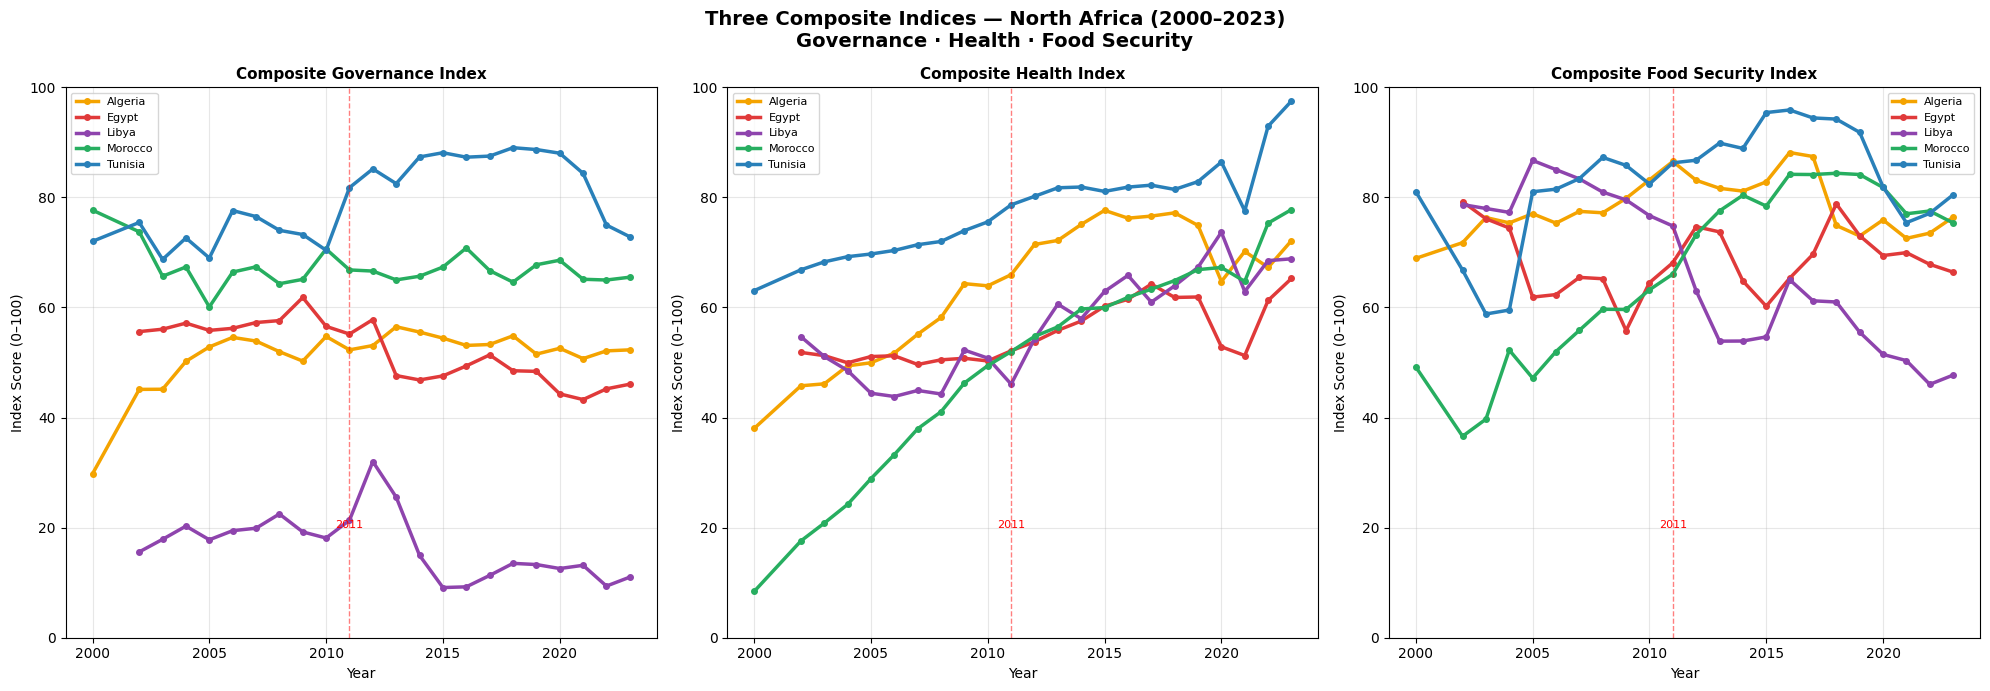

✅ composite_indices_three.png saved

=== INDEX CONSTRUCTION DOCUMENTATION ===

              Index                                                                  Components                                    Direction                               Missing data note
   Governance_Index Gov_Effectiveness + Rule_of_Law + Control_Corruption + Voice_Accountability    All positive → higher = better governance                   None — all countries complete
       Health_Index         Life_Expectancy + Health_Expenditure_GDP + (1 - Maternal_Mortality) Positive + inverted → higher = better health                   None — all countries complete
Food_Security_Index   SafeWater_pct + (1 - Undernourishment_pct) + (1 - FoodSupply_variability)        Mixed → higher = better food security SafeWater NaN for Egypt & Libya → partial index


In [19]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

df = pd.read_csv('north_africa_final_clean.csv')
df = df.sort_values(['Country', 'Year']).reset_index(drop=True)

scaler = MinMaxScaler()

# ============================================================
# INDEX 1 — GOVERNANCE INDEX
# All 4 indicators are positive (higher = better)
# ============================================================
gov_cols = ['Gov_Effectiveness', 'Rule_of_Law',
            'Control_Corruption', 'Voice_Accountability']

df_norm = df.copy()
df_norm[gov_cols] = scaler.fit_transform(df[gov_cols].fillna(df[gov_cols].mean()))
df['Governance_Index'] = df_norm[gov_cols].mean(axis=1) * 100

print("✅ Governance_Index: mean of 4 governance indicators (normalized 0–100)")

# ============================================================
# INDEX 2 — HEALTH INDEX (corrected — no food indicator)
# Positive: Life_Expectancy, Health_Expenditure_GDP
# Negative (inverted): Maternal_Mortality
# SafeWater_pct excluded — too many NaN (Egypt, Libya)
# ============================================================
health_pos = ['Life_Expectancy', 'Health_Expenditure_GDP']
health_inv = ['Maternal_Mortality']

df_norm[health_pos] = scaler.fit_transform(
    df[health_pos].fillna(df[health_pos].mean())
)
df_norm[health_inv] = 1 - scaler.fit_transform(
    df[health_inv].fillna(df[health_inv].mean())
)

df['Health_Index'] = df_norm[health_pos + health_inv].mean(axis=1) * 100

print("✅ Health_Index: Life_Expectancy + Health_Expenditure_GDP + (1 - Maternal_Mortality)")

# ============================================================
# INDEX 3 — FOOD SECURITY INDEX (new — was missing)
# Positive: SafeWater_pct (higher = better)
# Negative (inverted): Undernourishment_pct, FoodSupply_variability
# ============================================================
food_pos = ['SafeWater_pct']
food_inv = ['Undernourishment_pct', 'FoodSupply_variability']

# Note: SafeWater has NaN for Egypt and Libya
# We compute the index only where data is available
df_norm[food_pos] = scaler.fit_transform(
    df[food_pos].fillna(df[food_pos].mean())
)
df_norm[food_inv] = 1 - scaler.fit_transform(
    df[food_inv].fillna(df[food_inv].mean())
)

df['Food_Security_Index'] = df_norm[food_pos + food_inv].mean(axis=1) * 100

print("✅ Food_Security_Index: SafeWater_pct + (1 - Undernourishment) + (1 - FoodSupply_variability)")
print("   Note: SafeWater NaN for Egypt & Libya → their Food_Security_Index is partial")

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n=== THREE COMPOSITE INDICES — SUMMARY ===\n")
summary = df.groupby('Country')[
    ['Governance_Index', 'Health_Index', 'Food_Security_Index']
].mean().round(1)
print(summary)

# ============================================================
# VISUALIZATION — Three indices by country over time
# ============================================================
import matplotlib.pyplot as plt

colors = {
    'Algeria': '#F4A300', 'Egypt': '#E03A3A',
    'Libya': '#8E44AD', 'Morocco': '#27AE60', 'Tunisia': '#2980B9'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

index_info = [
    ('Governance_Index',     'Composite Governance Index',     'navy'),
    ('Health_Index',         'Composite Health Index',         'darkgreen'),
    ('Food_Security_Index',  'Composite Food Security Index',  'darkorange'),
]

for ax, (col, title, color) in zip(axes, index_info):
    for country in df['Country'].unique():
        sub = df[df['Country'] == country].dropna(subset=[col])
        ax.plot(sub['Year'], sub[col],
                color=colors[country], linewidth=2.5,
                marker='o', markersize=4, label=country)
    ax.axvline(x=2011, color='red', linestyle='--',
               alpha=0.5, linewidth=1)
    ax.annotate('2011', xy=(2011, 20), fontsize=8,
                color='red', ha='center')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Index Score (0–100)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 100)

fig.suptitle(
    'Three Composite Indices — North Africa (2000–2023)\n'
    'Governance · Health · Food Security',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('composite_indices_three.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ composite_indices_three.png saved")

# ============================================================
# DOCUMENTATION
# ============================================================
print("\n=== INDEX CONSTRUCTION DOCUMENTATION ===\n")
doc = pd.DataFrame({
    'Index': [
        'Governance_Index',
        'Health_Index',
        'Food_Security_Index'
    ],
    'Components': [
        'Gov_Effectiveness + Rule_of_Law + Control_Corruption + Voice_Accountability',
        'Life_Expectancy + Health_Expenditure_GDP + (1 - Maternal_Mortality)',
        'SafeWater_pct + (1 - Undernourishment_pct) + (1 - FoodSupply_variability)'
    ],
    'Direction': [
        'All positive → higher = better governance',
        'Positive + inverted → higher = better health',
        'Mixed → higher = better food security'
    ],
    'Missing data note': [
        'None — all countries complete',
        'None — all countries complete',
        'SafeWater NaN for Egypt & Libya → partial index'
    ]
})
print(doc.to_string(index=False))

📊 **Governance**
Governance trajectories diverge: Morocco and Tunisia steadily improve, Algeria rises moderately, Egypt stabilizes, while 
Libya collapses after 2011.  
🏥 **Health**
Tunisia leads in health outcomes, Morocco shows strong progress, Egypt and Algeria improve gradually, and Libya lags due to conflict.  
🍽️ **Food Security**
Food security remains fragile: Morocco advances, Algeria weakens post‑2015, Egypt stabilizes, Libya suffers conflict shocks, and Tunisia shifts from resilience after 2011 to sharp deterioration post‑2019.


## 6. Temporal Heatmap — Evolution by Country and Year

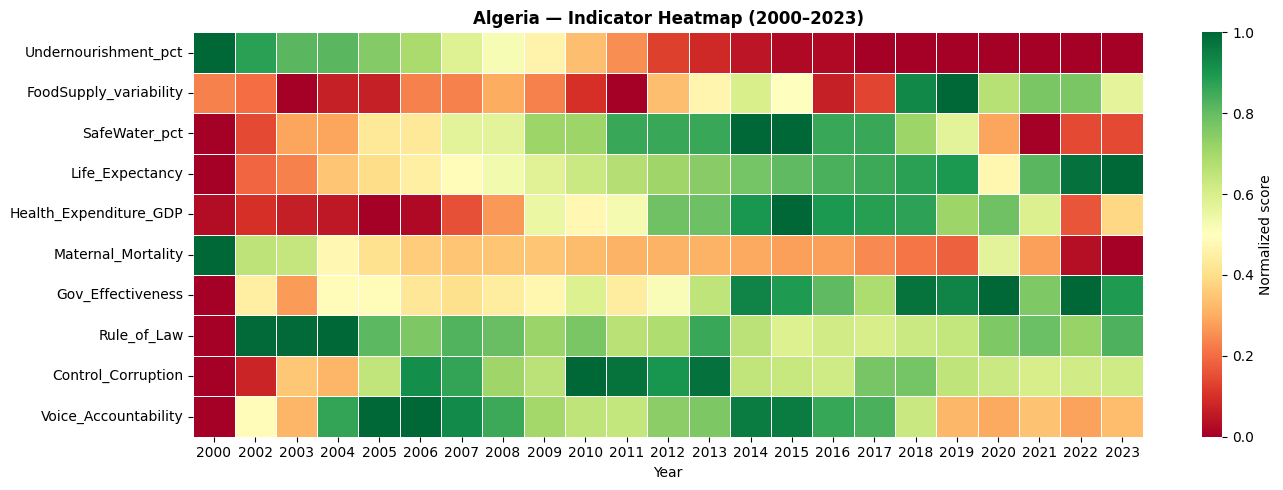

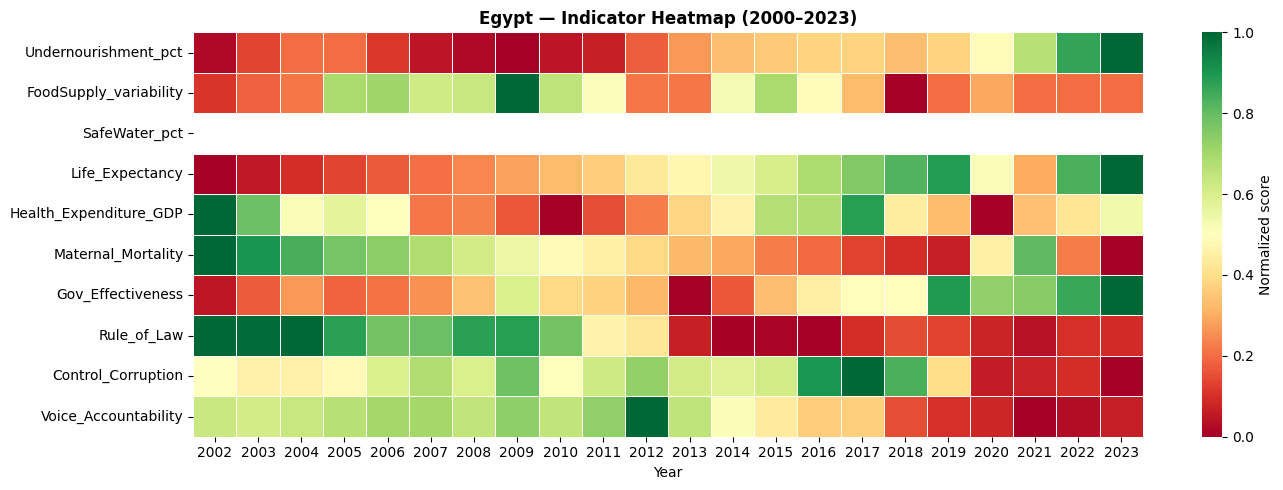

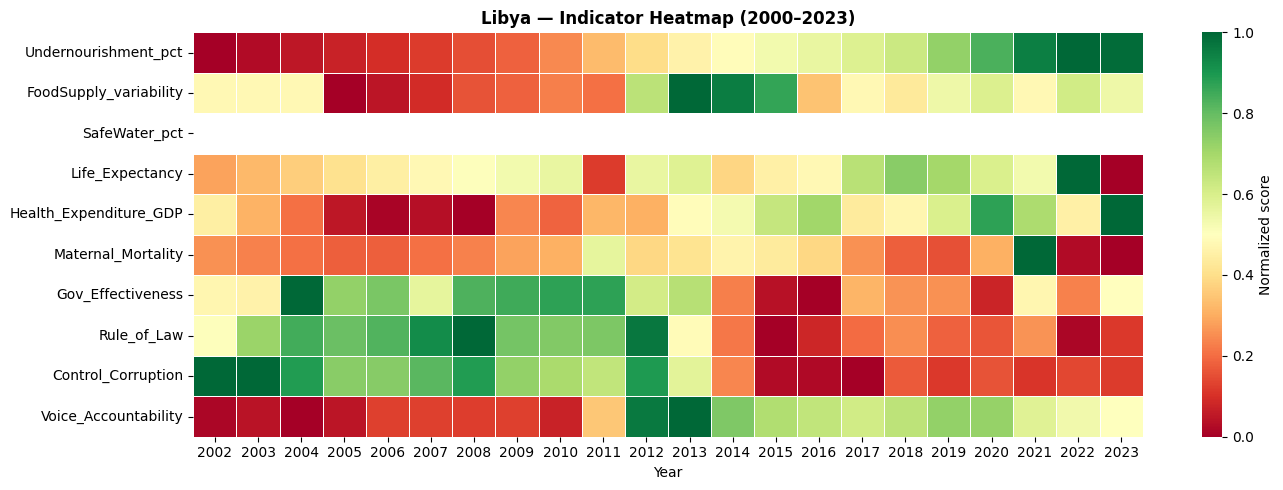

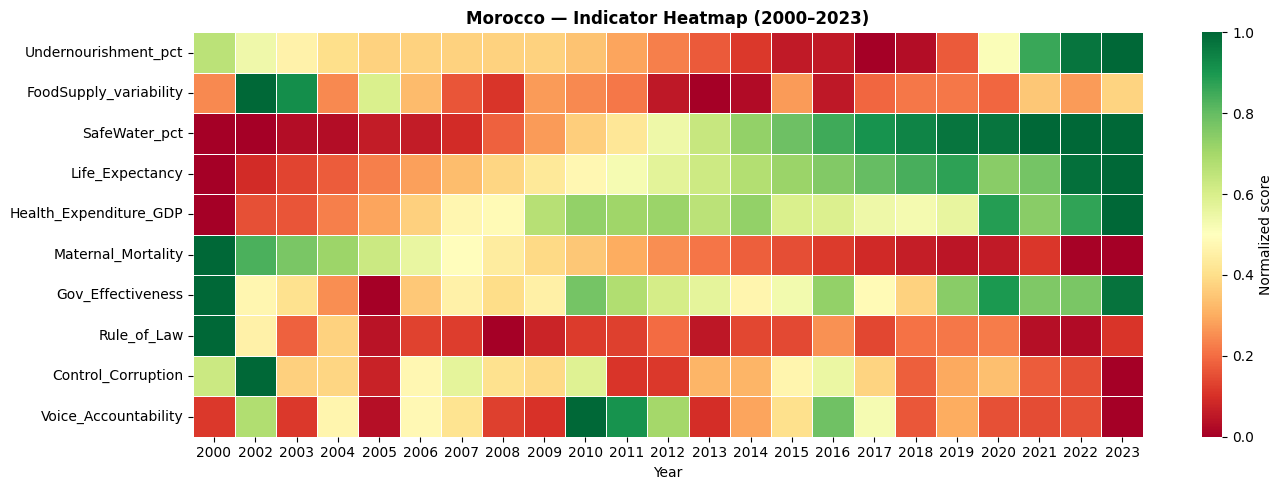

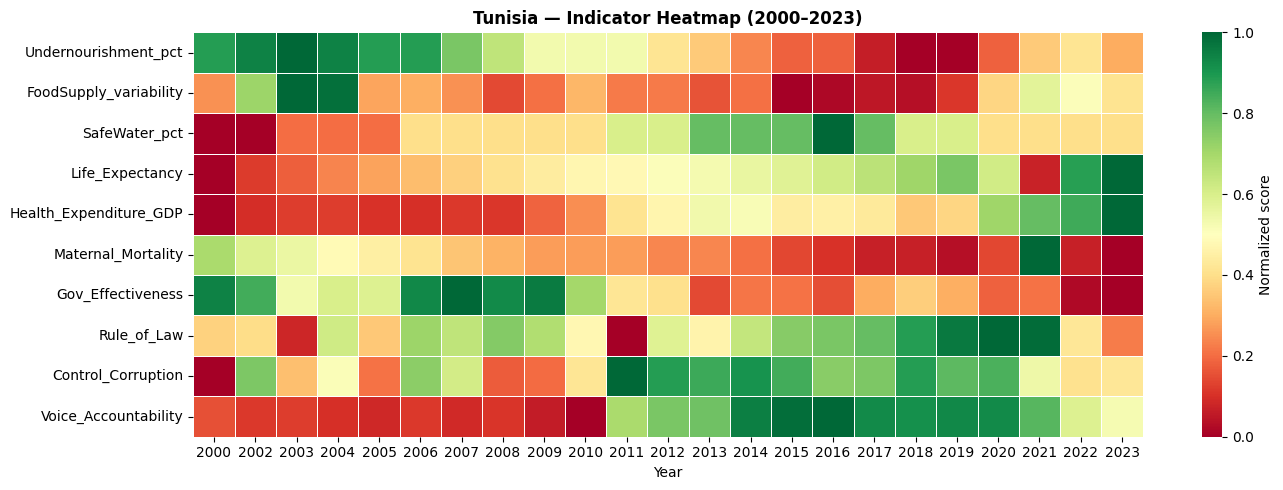

In [20]:
# ── Heatmap: Tunisia — all indicators over time ──
for country in df['Country'].unique():
    subset = df[df['Country'] == country].set_index('Year')[indicators]
    
    # Normalize for comparability
    subset_norm = (subset - subset.min()) / (subset.max() - subset.min())
    
    plt.figure(figsize=(14, 5))
    sns.heatmap(subset_norm.T, cmap='RdYlGn', annot=False,
                linewidths=0.5, cbar_kws={'label': 'Normalized score'})
    plt.title(f'{country} — Indicator Heatmap (2000–2023)',
              fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'heatmap_{country}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 📋 EDA Summary — Key Insights and Conclusions

This exploratory analysis of governance, health, and food security 
indicators across North Africa (2000–2023) yields eight evidence-based 
insights with direct relevance for development programming and M&E:

**1. Control of Corruption is the governance dimension most harmful 
to food security (r = −0.78)**
Among all governance indicators, corruption control has the strongest 
negative correlation with undernourishment — stronger than rule of law 
or government effectiveness. Anti-corruption policy is therefore the 
highest-leverage governance intervention for food security outcomes.

**2. Safe water access is more predictive of maternal survival 
than health expenditure**
SafeWater_pct and Maternal_Mortality show a correlation of r = −0.91, 
compared to r = −0.22 for Health_Expenditure_GDP. Infrastructure 
investment in water systems has greater returns for maternal health 
than financial expenditure on health services alone.

**3. Governance affects health outcomes indirectly through 
food security — not directly**
The mediation analysis (Paths A, B, C) reveals that governance 
improves life expectancy primarily by reducing undernourishment 
(Path A × Path B), not through a direct pathway (Path C, r = 0.24). 
This has major implications for programme design: health gains require 
food security intermediary investments.

**4. Morocco is the region's most coherent multi-dimensional 
reform model**
Morocco is the only country showing sustained simultaneous improvement 
across governance, health, and food security indicators over 23 years 
(+9 years life expectancy, −80% maternal mortality, safe water 
doubled). Its gradual constitutional reform approach (2011) produced 
more durable gains than rapid transitions.

**5. The Arab Spring produced real but temporary governance gains — 
only Morocco sustained the trajectory**
Voice and Accountability spiked across the region in 2011. By 2023, 
only Morocco maintained an upward trend. Tunisia reversed post-2019, 
Egypt collapsed, and Libya remains in institutional fragmentation.

**6. Food supply variability does not correlate with structural 
indicators — it captures episodic shocks**
FoodSupply_variability shows near-zero correlations across all other 
variables (r ≈ 0) because it measures volatility, not levels. Its 
spikes align with conflict years (Libya 2011, 2014) and political 
transitions (Tunisia 2019–2020), confirming it as a crisis detection 
indicator rather than a development trend indicator.

**7. Tunisia presents a paradox: best health outcomes, 
deteriorating governance**
Despite governance decline post-2019 (Control of Corruption, 
Voice and Accountability), Tunisia maintains the region's best 
health performance. This suggests that health system institutional 
inertia can buffer short-term political deterioration — but this 
resilience has limits if governance continues to weaken.

**8. Libya's institutional collapse is total and multi-dimensional**
Post-2011, Libya shows simultaneous deterioration across all 10 
indicators — the only country where no indicator improved after 
the political transition. This makes Libya a textbook case study 
in how conflict destroys institutional capital across all 
development dimensions simultaneously.

---
*This EDA was conducted as part of a Data Science portfolio project 
applying M&E methodologies to multi-source development data. 
Data sources: FAOSTAT, World Bank WGI, WHO Global Health Observatory. 
Period: 2000–2023. Countries: Algeria, Egypt, Libya, Morocco, Tunisia.*

## Automatic Report

In [19]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport
# Generate profile
profile = ProfileReport(df, title="Data Profiling Report", explorative=True)

# Export to HTML
profile.to_file("report.html")



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 869.3 kB/s eta 0:00:03
   ----------- ---------------------------- 0.8/2.7 MB 903.8 kB/s eta 0:00:03
   --------------- ------------------------ 1.0/2.7 MB 942.9 kB/s eta 0:00:02
   ------------------- -------------------- 1.3/2.7 MB 993.4 kB/s eta 0:00:02
   ---------------------- ----------------- 1.6/2.7 MB 1.0 MB/s eta 0:00:02
   -------------------------- ------------- 1.8/2.7 MB 1.1 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.7 MB 1.1 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.7 MB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 1.2 MB/s  0:00:02
   --------------------------------

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 42432.65it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [20]:
!pip install sweetviz

import sweetviz as sv

report = sv.analyze(df)
report.show_html("sweetviz_report.html")

# Comparaison avant/après 2011
pre_2011 = df[df['Year'] < 2011]
post_2011 = df[df['Year'] >= 2011]
report_compare = sv.compare([pre_2011, "Pre-2011"],
                             [post_2011, "Post-2011"])
report_compare.show_html("sweetviz_arab_spring_compare.html")

   ---------------------------------------- 0.0/15.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.1 MB ? eta -:--:--
   -- ------------------------------------- 1.0/15.1 MB 5.0 MB/s eta 0:00:03
   ------ --------------------------------- 2.6/15.1 MB 6.2 MB/s eta 0:00:03
   ----------- ---------------------------- 4.2/15.1 MB 6.8 MB/s eta 0:00:02
   ---------------- ----------------------- 6.3/15.1 MB 7.5 MB/s eta 0:00:02
   ---------------------- ----------------- 8.4/15.1 MB 8.2 MB/s eta 0:00:01
   ----------------------------- ---------- 11.0/15.1 MB 8.8 MB/s eta 0:00:01
   ------------------------------- -------- 11.8/15.1 MB 8.5 MB/s eta 0:00:01
   --------------------------------- ------ 12.8/15.1 MB 7.7 MB/s eta 0:00:01
   ------------------------------------ --- 13.9/15.1 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------  14.9/15.1 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 15.1/15.1 MB 7.2 MB/s  0:00:02

   ------


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_arab_spring_compare.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
